# CKD Dataset —  Pre-Modeling Audit & EDA

**Dataset:** Kaggle `mansoordaku/ckdisease`  
**Expected Kaggle path:** `/kaggle/input/datasets/mansoordaku/ckdisease`

This notebook performs a **scientific pre-modeling audit** before any ML/DL model is trained.

It covers:

- dataset structure and raw-value audit
- deterministic data cleaning
- target and class-imbalance analysis
- duplicates, constants, near-constants
- missingness amount, pattern, and outcome association
- descriptive statistics, skewness, kurtosis, normality diagnostics
- numerical/categorical distributions
- clinically suspicious value screening
- statistical and robust outlier analysis
- feature–target association tests + effect sizes + FDR correction
- nonlinear screening via mutual information
- correlation, redundancy, and VIF
- leakage diagnostics, including `id`
- scientifically defensible splitting strategy
- preprocessing pipeline templates for the next stage
- export of all major tables/results



In [4]:
# ============================================================
# 0. IMPORTS AND REPRODUCIBILITY
# ============================================================

import os
import re
import json
import math
import warnings
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import (
    chi2_contingency,
    fisher_exact,
    mannwhitneyu,
    ttest_ind,
    shapiro
)

from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold

from statsmodels.stats.multitest import multipletests
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_context("notebook")

OUTPUT_DIR = Path("/kaggle/working/ckd_eda_outputs")
FIG_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Output directory:", OUTPUT_DIR)

Output directory: /kaggle/working/ckd_eda_outputs


## 1. Locate and Load the Dataset

The code searches the supplied Kaggle directory recursively for CSV files, prints all candidates, and loads the most likely CKD file.

In [5]:
# ============================================================
# 1. LOCATE DATASET
# ============================================================

DATA_ROOT = Path("/kaggle/input/datasets/mansoordaku/ckdisease")

if not DATA_ROOT.exists():
    # Kaggle sometimes exposes datasets one level differently.
    fallback_roots = [
        Path("/kaggle/input/ckdisease"),
        Path("/kaggle/input"),
    ]
    existing = [p for p in fallback_roots if p.exists()]
    if existing:
        DATA_ROOT = existing[0]

csv_files = sorted(DATA_ROOT.rglob("*.csv"))

print("Search root:", DATA_ROOT)
print("\nCSV files found:")
for i, p in enumerate(csv_files):
    print(f"[{i}] {p}")

if not csv_files:
    raise FileNotFoundError(
        "No CSV file was found. Open Kaggle's Data panel and confirm the dataset is attached."
    )

# Prefer a filename containing 'kidney' or 'ckd'
preferred = [
    p for p in csv_files
    if ("kidney" in p.name.lower() or "ckd" in p.name.lower())
]
DATA_PATH = preferred[0] if preferred else csv_files[0]

print("\nUsing:", DATA_PATH)

raw = pd.read_csv(DATA_PATH)
print("\nRaw shape:", raw.shape)
display(raw.head())

Search root: /kaggle/input/datasets/mansoordaku/ckdisease

CSV files found:
[0] /kaggle/input/datasets/mansoordaku/ckdisease/kidney_disease.csv

Using: /kaggle/input/datasets/mansoordaku/ckdisease/kidney_disease.csv

Raw shape: (400, 26)


,id,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0000,80.0000,1.0200,1.0000,0.0000,NaN,normal,notpresent,notpresent,121.0000,36.0000,1.2000,NaN,NaN,15.4000,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0000,50.0000,1.0200,4.0000,0.0000,NaN,normal,notpresent,notpresent,NaN,18.0000,0.8000,NaN,NaN,11.3000,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0000,80.0000,1.0100,2.0000,3.0000,normal,normal,notpresent,notpresent,423.0000,53.0000,1.8000,NaN,NaN,9.6000,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0000,70.0000,1.0050,4.0000,0.0000,normal,abnormal,present,notpresent,117.0000,56.0000,3.8000,111.0000,2.5000,11.2000,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0000,80.0000,1.0100,2.0000,0.0000,normal,normal,notpresent,notpresent,106.0000,26.0000,1.4000,NaN,NaN,11.6000,35,7300,4.6,no,no,no,good,no,no,ckd


In [6]:
# Save untouched raw copy in Kaggle working directory
raw.to_csv(OUTPUT_DIR / "raw_snapshot.csv", index=False)

print("Raw columns:")
print(list(raw.columns))

print("\nRaw dtypes:")
display(raw.dtypes.to_frame("dtype"))

print("\nRaw info:")
raw.info()

Raw columns:
['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'classification']

Raw dtypes:


,dtype
id,int64
age,float64
bp,float64
sg,float64
al,float64
su,float64
rbc,object
pc,object
pcc,object
ba,object



Raw info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-

## 2. Raw-Value Audit Before Cleaning

This is essential because this CKD dataset is known to contain whitespace/tab-contaminated labels and numeric-looking values stored as strings.

We first inspect all object/string columns *before* modifying them.

In [40]:
# ============================================================
# 2. RAW OBJECT/CATEGORICAL VALUE AUDIT — FIXED
# ============================================================

raw_object_cols = raw.select_dtypes(
    include=["object", "string"]
).columns.tolist()

print("Raw object/string columns:")
print(raw_object_cols)

raw_unique_tables = []

for col in raw_object_cols:

    # Frequency table including missing values
    vc = raw[col].value_counts(dropna=False)

    # Robust conversion to a consistent 3-column structure
    temp = (
        vc.rename_axis("raw_value")
          .reset_index(name="count")
    )

    # Add source feature name
    temp.insert(0, "feature", col)

    raw_unique_tables.append(temp)

# Combine all variables
if raw_unique_tables:
    raw_unique_audit = pd.concat(
        raw_unique_tables,
        ignore_index=True
    )
else:
    raw_unique_audit = pd.DataFrame(
        columns=["feature", "raw_value", "count"]
    )

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

print("\nShape of audit table:")
print(raw_unique_audit.shape)

print("\nColumns:")
print(raw_unique_audit.columns.tolist())

assert raw_unique_audit.columns.tolist() == [
    "feature",
    "raw_value",
    "count"
], "Unexpected audit-table structure."

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

display(raw_unique_audit.head(150))

# Save
raw_unique_audit.to_csv(
    OUTPUT_DIR / "raw_object_value_audit.csv",
    index=False
)

print(
    "\nSaved:",
    OUTPUT_DIR / "raw_object_value_audit.csv"
)

Raw object/string columns:
['rbc', 'pc', 'pcc', 'ba', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'classification']

Shape of audit table:
(225, 3)

Columns:
['feature', 'raw_value', 'count']


,feature,raw_value,count
0,rbc,normal,201
1,rbc,NaN,152
2,rbc,abnormal,47
3,pc,normal,259
4,pc,abnormal,76
5,pc,NaN,65
6,pcc,notpresent,354
7,pcc,present,42
8,pcc,NaN,4
9,ba,notpresent,374



Saved: /kaggle/working/ckd_eda_outputs/raw_object_value_audit.csv


## 3. Deterministic Cleaning

This cleaning is **not learned from the target** and is therefore appropriate before validation splitting:

- normalize column names
- strip spaces/tabs from string cells
- convert common missing markers to `NaN`
- canonicalize target/category spellings
- convert clinically numeric columns to numeric
- preserve an audit of values that fail numeric conversion

No statistical imputation is performed here.

In [8]:
# ============================================================
# 3. DETERMINISTIC CLEANING
# ============================================================

df = raw.copy()

# Normalize column names
df.columns = (
    df.columns.astype(str)
    .str.strip()
    .str.lower()
    .str.replace(r"\s+", "_", regex=True)
)

# Common aliases if a slightly different file version is encountered
COLUMN_ALIASES = {
    "classification": "classification",
    "class": "classification",
    "target": "classification",
    "blood_pressure": "bp",
    "specific_gravity": "sg",
    "albumin": "al",
    "sugar": "su",
    "red_blood_cells": "rbc",
    "pus_cell": "pc",
    "pus_cell_clumps": "pcc",
    "bacteria": "ba",
    "blood_glucose_random": "bgr",
    "blood_urea": "bu",
    "serum_creatinine": "sc",
    "sodium": "sod",
    "potassium": "pot",
    "hemoglobin": "hemo",
    "packed_cell_volume": "pcv",
    "white_blood_cell_count": "wc",
    "red_blood_cell_count": "rc",
    "hypertension": "htn",
    "diabetes_mellitus": "dm",
    "coronary_artery_disease": "cad",
    "appetite": "appet",
    "pedal_edema": "pe",
    "anemia": "ane",
}

df = df.rename(columns={c: COLUMN_ALIASES.get(c, c) for c in df.columns})

# Strip whitespace/tabs from all string-like columns
for col in df.select_dtypes(include=["object", "string"]).columns:
    df[col] = df[col].astype("string").str.strip()

# Standardize missing markers
MISSING_MARKERS = {
    "", "?", "??", "na", "n/a", "nan", "none", "null",
    "<na>", "-", "--", "missing"
}

for col in df.select_dtypes(include=["object", "string"]).columns:
    lower = df[col].str.lower()
    df.loc[lower.isin(MISSING_MARKERS), col] = pd.NA

# Lowercase categorical strings after stripping
for col in df.select_dtypes(include=["object", "string"]).columns:
    df[col] = df[col].str.lower()

# Canonicalize target
if "classification" not in df.columns:
    raise KeyError("Target column 'classification' was not found after column normalization.")

target_map = {
    "ckd": "ckd",
    "notckd": "notckd",
    "not ckd": "notckd",
    "nonckd": "notckd",
    "non-ckd": "notckd",
    "0": "notckd",
    "1": "ckd",
}
df["classification"] = df["classification"].replace(target_map)

# Canonicalize common binary/categorical values
canonical_replacements = {
    "yes": "yes",
    "no": "no",
    "present": "present",
    "notpresent": "notpresent",
    "not present": "notpresent",
    "normal": "normal",
    "abnormal": "abnormal",
    "good": "good",
    "poor": "poor",
}

categorical_candidates = [
    "rbc", "pc", "pcc", "ba", "htn", "dm", "cad",
    "appet", "pe", "ane", "classification"
]

for col in categorical_candidates:
    if col in df.columns:
        df[col] = df[col].replace(canonical_replacements)

# Expected numeric variables for the canonical UCI CKD dataset
EXPECTED_NUMERIC = [
    "id", "age", "bp", "sg", "al", "su", "bgr", "bu",
    "sc", "sod", "pot", "hemo", "pcv", "wc", "rc"
]

numeric_conversion_audit = []

for col in [c for c in EXPECTED_NUMERIC if c in df.columns]:
    original = df[col].copy()
    converted = pd.to_numeric(original, errors="coerce")

    failed = original.notna() & converted.isna()
    if failed.any():
        vals = original[failed].astype(str).value_counts()
        for val, count in vals.items():
            numeric_conversion_audit.append({
                "feature": col,
                "unparsed_value": val,
                "count": int(count)
            })

    df[col] = converted

numeric_conversion_audit = pd.DataFrame(numeric_conversion_audit)

print("Cleaned shape:", df.shape)
print("\nTarget values after cleaning:")
display(df["classification"].value_counts(dropna=False).to_frame("count"))

print("\nNumeric conversion failures:")
display(numeric_conversion_audit if len(numeric_conversion_audit) else pd.DataFrame({"message":["None"]}))

numeric_conversion_audit.to_csv(OUTPUT_DIR / "numeric_conversion_audit.csv", index=False)
df.to_csv(OUTPUT_DIR / "cleaned_preimputation_data.csv", index=False)

Cleaned shape: (400, 26)

Target values after cleaning:


,count
classification,
ckd,250
notckd,150



Numeric conversion failures:


,message
0,None


## 4. Dataset Structure, Types, Uniqueness, Duplicates, Constant/Near-Constant Features

In [9]:
# ============================================================
# 4. STRUCTURAL AUDIT
# ============================================================

target_col = "classification"
id_col = "id" if "id" in df.columns else None

predictor_cols = [c for c in df.columns if c not in [target_col]]
model_predictors = [c for c in predictor_cols if c != id_col]

numeric_cols = df[model_predictors].select_dtypes(include=np.number).columns.tolist()
categorical_cols = [c for c in model_predictors if c not in numeric_cols]

structure = pd.DataFrame({
    "feature": df.columns,
    "dtype": [str(df[c].dtype) for c in df.columns],
    "n_non_missing": [int(df[c].notna().sum()) for c in df.columns],
    "n_missing": [int(df[c].isna().sum()) for c in df.columns],
    "missing_pct": [100 * df[c].isna().mean() for c in df.columns],
    "n_unique_non_missing": [int(df[c].nunique(dropna=True)) for c in df.columns],
})

# Dominant level/frequency
dominant_values = []
dominant_pct = []

for c in df.columns:
    vc = df[c].value_counts(dropna=True, normalize=True)
    dominant_values.append(vc.index[0] if len(vc) else np.nan)
    dominant_pct.append(100 * vc.iloc[0] if len(vc) else np.nan)

structure["dominant_value"] = dominant_values
structure["dominant_pct"] = dominant_pct
structure["constant"] = structure["n_unique_non_missing"] <= 1

# Conservative flag only; NOT an automatic deletion rule
structure["near_constant_95pct"] = structure["dominant_pct"] >= 95

display(structure)
structure.to_csv(OUTPUT_DIR / "dataset_structure.csv", index=False)

print("Numeric predictors:", numeric_cols)
print("Categorical predictors:", categorical_cols)

# Duplicate audit
raw_dup = int(raw.duplicated().sum())
clean_dup_all = int(df.duplicated().sum())

if id_col:
    clean_dup_excluding_id = int(df.drop(columns=[id_col]).duplicated().sum())
else:
    clean_dup_excluding_id = clean_dup_all

duplicate_summary = pd.DataFrame({
    "check": [
        "Exact duplicates in raw table",
        "Exact duplicates after deterministic cleaning",
        "Duplicates after excluding ID"
    ],
    "count": [raw_dup, clean_dup_all, clean_dup_excluding_id]
})

display(duplicate_summary)
duplicate_summary.to_csv(OUTPUT_DIR / "duplicate_summary.csv", index=False)

if clean_dup_excluding_id > 0:
    cols_for_dup = [c for c in df.columns if c != id_col]
    duplicate_rows = df[df.duplicated(subset=cols_for_dup, keep=False)].sort_values(cols_for_dup)
    display(duplicate_rows.head(50))
    duplicate_rows.to_csv(OUTPUT_DIR / "duplicate_rows_excluding_id.csv", index=False)

,feature,dtype,n_non_missing,n_missing,missing_pct,n_unique_non_missing,dominant_value,dominant_pct,constant,near_constant_95pct
0,id,int64,400,0,0.0000,400,399,0.2500,False,False
1,age,float64,391,9,2.2500,76,60.0000,4.8593,False,False
2,bp,float64,388,12,3.0000,10,80.0000,29.8969,False,False
3,sg,float64,353,47,11.7500,5,1.0200,30.0283,False,False
4,al,float64,354,46,11.5000,6,0.0000,56.2147,False,False
5,su,float64,351,49,12.2500,6,0.0000,82.6211,False,False
6,rbc,string,248,152,38.0000,2,normal,81.0484,False,False
7,pc,string,335,65,16.2500,2,normal,77.3134,False,False
8,pcc,string,396,4,1.0000,2,notpresent,89.3939,False,False
9,ba,string,396,4,1.0000,2,notpresent,94.4444,False,False


Numeric predictors: ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc']
Categorical predictors: ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']


,check,count
0,Exact duplicates in raw table,0
1,Exact duplicates after deterministic cleaning,0
2,Duplicates after excluding ID,0


## 5. Target Distribution and Class Imbalance

,count,percent
classification,,
ckd,250,62.5000
notckd,150,37.5000


Imbalance ratio (majority/minority): 1.667:1


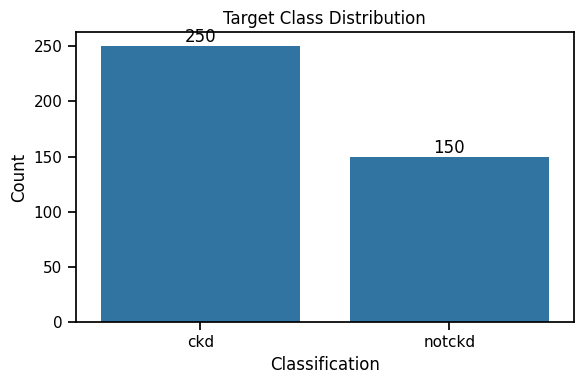

In [10]:
# ============================================================
# 5. TARGET / CLASS IMBALANCE
# ============================================================

target_counts = df[target_col].value_counts(dropna=False)
target_pct = 100 * df[target_col].value_counts(dropna=False, normalize=True)

class_summary = pd.DataFrame({
    "count": target_counts,
    "percent": target_pct
})

display(class_summary)
class_summary.to_csv(OUTPUT_DIR / "class_distribution.csv")

valid_target = df[target_col].dropna()
if valid_target.nunique() == 2:
    counts = valid_target.value_counts()
    majority = counts.max()
    minority = counts.min()
    imbalance_ratio = majority / minority
    print(f"Imbalance ratio (majority/minority): {imbalance_ratio:.3f}:1")
else:
    imbalance_ratio = np.nan

plt.figure(figsize=(6,4))
ax = sns.countplot(data=df, x=target_col, order=df[target_col].value_counts().index)
plt.title("Target Class Distribution")
plt.xlabel("Classification")
plt.ylabel("Count")
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.savefig(FIG_DIR / "target_class_distribution.png", dpi=180)
plt.show()

## 6. Missing-Data Audit

We measure:

- missing count and percentage
- missingness by CKD class
- difference in missingness rates between classes
- χ²/Fisher tests for association between **missingness indicator** and outcome
- missingness-indicator correlation matrix

A statistically significant missingness–outcome association does **not** by itself prove MNAR. It shows that missingness is outcome-associated and therefore should not be assumed to be completely random.

,feature,missing_n,missing_pct
5,rbc,152,38.0000
17,rc,131,32.7500
16,wc,106,26.5000
13,pot,88,22.0000
12,sod,87,21.7500
15,pcv,71,17.7500
6,pc,65,16.2500
14,hemo,52,13.0000
4,su,49,12.2500
2,sg,47,11.7500


Rows with ≥1 missing predictor: 242/400 (60.50%)
Complete predictor rows: 158/400 (39.50%)


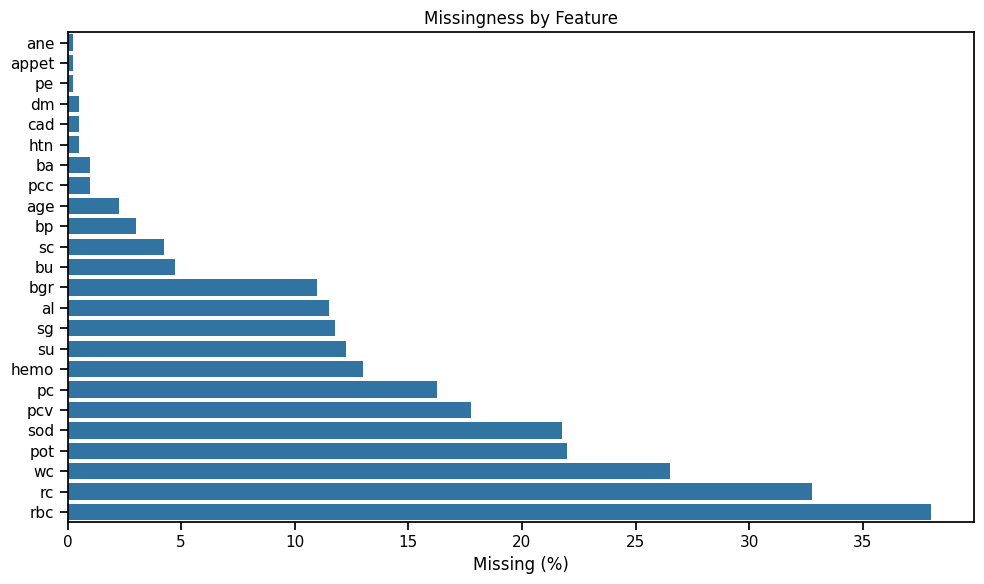

In [11]:
# ============================================================
# 6. MISSINGNESS SUMMARY
# ============================================================

missing_summary = pd.DataFrame({
    "feature": model_predictors,
    "missing_n": [int(df[c].isna().sum()) for c in model_predictors],
    "missing_pct": [100 * df[c].isna().mean() for c in model_predictors],
}).sort_values("missing_pct", ascending=False)

display(missing_summary)
missing_summary.to_csv(OUTPUT_DIR / "missingness_summary.csv", index=False)

n_rows_with_missing = int(df[model_predictors].isna().any(axis=1).sum())
n_complete = int((~df[model_predictors].isna().any(axis=1)).sum())

print(f"Rows with ≥1 missing predictor: {n_rows_with_missing}/{len(df)} ({100*n_rows_with_missing/len(df):.2f}%)")
print(f"Complete predictor rows: {n_complete}/{len(df)} ({100*n_complete/len(df):.2f}%)")

plt.figure(figsize=(10,6))
plot_missing = missing_summary[missing_summary["missing_n"] > 0].sort_values("missing_pct")
sns.barplot(data=plot_missing, x="missing_pct", y="feature")
plt.title("Missingness by Feature")
plt.xlabel("Missing (%)")
plt.ylabel("")
plt.tight_layout()
plt.savefig(FIG_DIR / "missingness_by_feature.png", dpi=180)
plt.show()

In [12]:
# Missingness by target class
missing_by_target_rows = []

for col in model_predictors:
    temp = pd.DataFrame({
        "target": df[target_col],
        "missing": df[col].isna().astype(int)
    }).dropna(subset=["target"])

    rates = temp.groupby("target")["missing"].agg(["sum", "count", "mean"])
    for cls, row in rates.iterrows():
        missing_by_target_rows.append({
            "feature": col,
            "class": cls,
            "missing_n": int(row["sum"]),
            "class_n": int(row["count"]),
            "missing_pct": 100 * row["mean"]
        })

missing_by_target = pd.DataFrame(missing_by_target_rows)
display(missing_by_target.head(60))
missing_by_target.to_csv(OUTPUT_DIR / "missingness_by_target.csv", index=False)

# Wide view
missing_by_target_wide = missing_by_target.pivot(
    index="feature", columns="class", values="missing_pct"
)

if {"ckd", "notckd"}.issubset(missing_by_target_wide.columns):
    missing_by_target_wide["abs_diff_pct_points"] = (
        missing_by_target_wide["ckd"] - missing_by_target_wide["notckd"]
    ).abs()
    missing_by_target_wide = missing_by_target_wide.sort_values(
        "abs_diff_pct_points", ascending=False
    )

display(missing_by_target_wide)
missing_by_target_wide.to_csv(OUTPUT_DIR / "missingness_by_target_wide.csv")

,feature,class,missing_n,class_n,missing_pct
0,age,ckd,8,250,3.2000
1,age,notckd,1,150,0.6667
2,bp,ckd,10,250,4.0000
3,bp,notckd,2,150,1.3333
4,sg,ckd,42,250,16.8000
5,sg,notckd,5,150,3.3333
6,al,ckd,41,250,16.4000
7,al,notckd,5,150,3.3333
8,su,ckd,44,250,17.6000
9,su,notckd,5,150,3.3333


class,ckd,notckd,abs_diff_pct_points
feature,,,
rbc,57.2000,6.0000,51.2000
rc,49.6000,4.6667,44.9333
wc,39.6000,4.6667,34.9333
pot,33.2000,3.3333,29.8667
sod,32.8000,3.3333,29.4667
pcv,26.8000,2.6667,24.1333
pc,22.4000,6.0000,16.4000
hemo,18.4000,4.0000,14.4000
su,17.6000,3.3333,14.2667


In [13]:
# Statistical association: missingness indicator vs target
missing_assoc = []

for col in model_predictors:
    temp = pd.DataFrame({
        "target": df[target_col],
        "missing": df[col].isna().astype(int)
    }).dropna(subset=["target"])

    table = pd.crosstab(temp["missing"], temp["target"])

    if table.shape[0] < 2 or table.shape[1] < 2:
        missing_assoc.append({
            "feature": col,
            "test": "not_testable",
            "p_value": np.nan,
            "cramers_v": np.nan
        })
        continue

    # 2x2 Fisher if expected cells are small; otherwise chi-square
    chi2, p_chi, dof, expected = chi2_contingency(table)
    use_fisher = table.shape == (2,2) and (expected < 5).any()

    if use_fisher:
        _, p = fisher_exact(table.values)
        test_name = "Fisher exact"
    else:
        p = p_chi
        test_name = "Chi-square"

    n = table.values.sum()
    r, k = table.shape
    cramers_v = math.sqrt(chi2 / (n * max(1, min(k - 1, r - 1))))

    missing_assoc.append({
        "feature": col,
        "test": test_name,
        "p_value": p,
        "cramers_v": cramers_v
    })

missing_assoc = pd.DataFrame(missing_assoc)

mask = missing_assoc["p_value"].notna()
missing_assoc["p_fdr_bh"] = np.nan
if mask.sum():
    missing_assoc.loc[mask, "p_fdr_bh"] = multipletests(
        missing_assoc.loc[mask, "p_value"],
        method="fdr_bh"
    )[1]

missing_assoc["fdr_significant_0.05"] = missing_assoc["p_fdr_bh"] < 0.05
missing_assoc = missing_assoc.sort_values(["p_fdr_bh", "cramers_v"], ascending=[True, False])

display(missing_assoc)
missing_assoc.to_csv(OUTPUT_DIR / "missingness_target_association.csv", index=False)

,feature,test,p_value,cramers_v,p_fdr_bh,fdr_significant_0.05
5,rbc,Chi-square,0.0000,0.5053,0.0000,True
17,rc,Chi-square,0.0000,0.4580,0.0000,True
16,wc,Chi-square,0.0000,0.3774,0.0000,True
13,pot,Chi-square,0.0000,0.3428,0.0000,True
12,sod,Chi-square,0.0000,0.3395,0.0000,True
15,pcv,Chi-square,0.0000,0.2990,0.0000,True
6,pc,Chi-square,0.0000,0.2082,0.0001,True
4,su,Chi-square,0.0000,0.2028,0.0001,True
14,hemo,Chi-square,0.0001,0.1996,0.0002,True
2,sg,Chi-square,0.0001,0.1944,0.0002,True


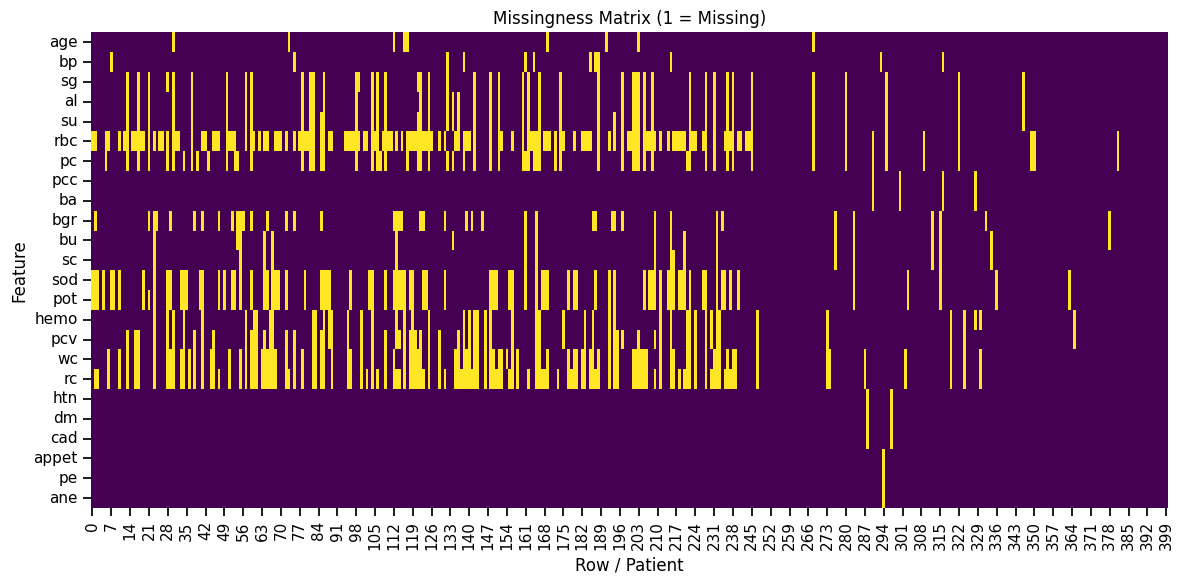

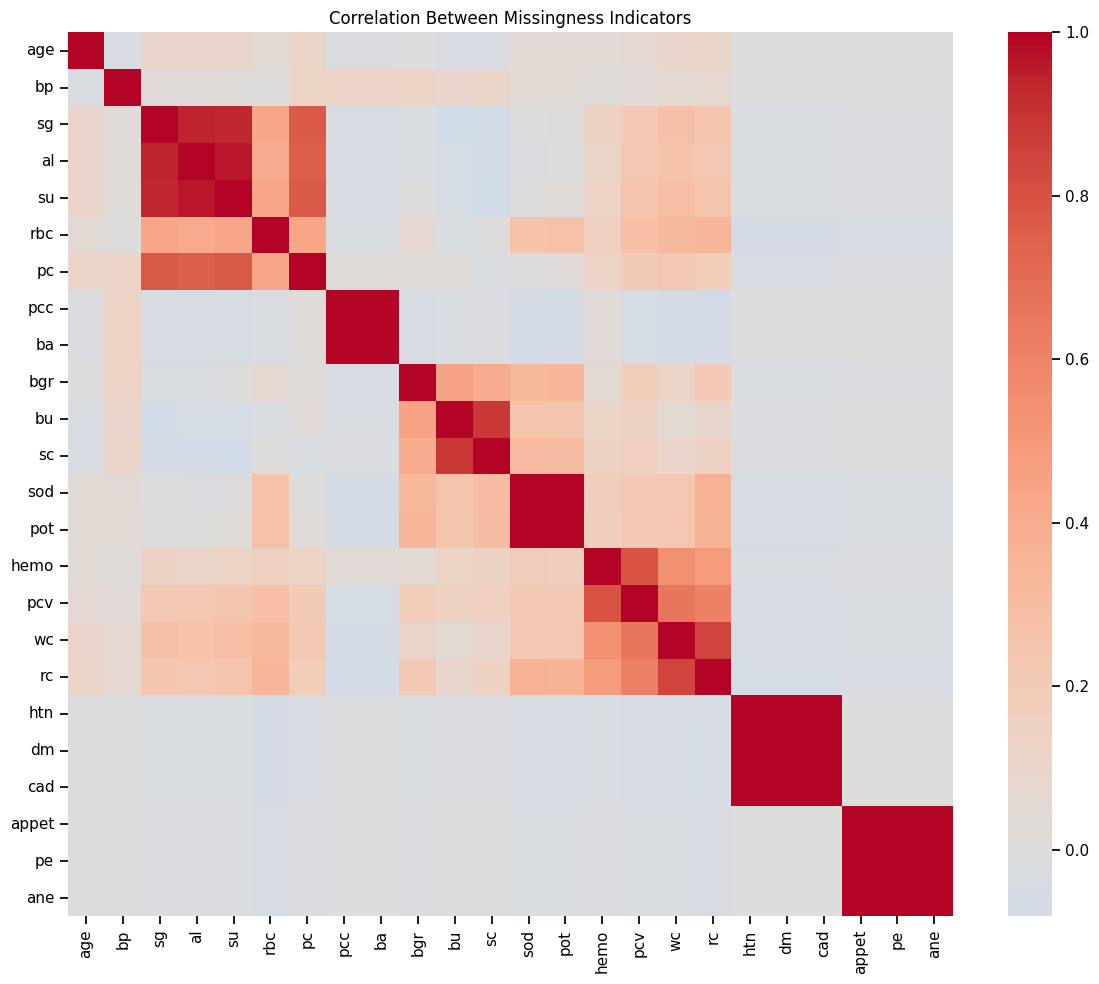

In [14]:
# Missingness-pattern visualization
missing_indicator = df[model_predictors].isna().astype(int)
cols_with_missing = missing_indicator.columns[missing_indicator.sum() > 0].tolist()

if cols_with_missing:
    plt.figure(figsize=(12,6))
    sns.heatmap(
        missing_indicator[cols_with_missing].T,
        cmap="viridis",
        cbar=False,
        yticklabels=True
    )
    plt.title("Missingness Matrix (1 = Missing)")
    plt.xlabel("Row / Patient")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "missingness_matrix.png", dpi=180)
    plt.show()

    miss_corr = missing_indicator[cols_with_missing].corr(method="spearman")
    plt.figure(figsize=(12,10))
    sns.heatmap(miss_corr, cmap="coolwarm", center=0)
    plt.title("Correlation Between Missingness Indicators")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "missingness_indicator_correlation.png", dpi=180)
    plt.show()

    miss_corr.to_csv(OUTPUT_DIR / "missingness_indicator_correlation.csv")

## 7. Clinical Plausibility / Data-Entry Screening

The ranges below are deliberately **very broad sanity bounds**, not diagnostic reference ranges. Their purpose is only to flag values that may reflect transcription, decimal-point, or unit errors.

**Do not automatically delete or winsorize flagged observations.** They require source verification or clinical review.

Edit the bounds if your clinical team prefers different conservative plausibility limits.

In [15]:
# ============================================================
# 7. CLINICAL PLAUSIBILITY SCREEN
# ============================================================

# Broad sanity ranges for data-quality review, not normal reference intervals.
PLAUSIBILITY_RANGES = {
    "age":  (0, 120),
    "bp":   (30, 300),        # mmHg, broad data-entry sanity bound
    "sg":   (1.000, 1.060),   # urine specific gravity
    "al":   (0, 5),           # ordinal grade
    "su":   (0, 5),           # ordinal grade
    "bgr":  (10, 1000),       # mg/dL
    "bu":   (1, 500),         # mg/dL
    "sc":   (0.1, 100),       # mg/dL
    "sod":  (100, 180),       # mEq/L: broad physiological sanity screen
    "pot":  (1.5, 10),        # mEq/L: broad physiological sanity screen
    "hemo": (1, 25),          # g/dL
    "pcv":  (5, 75),          # %
    "wc":   (500, 100000),    # cells/cumm
    "rc":   (1, 10),          # millions/cumm
}

plausibility_flags = []

for col, (low, high) in PLAUSIBILITY_RANGES.items():
    if col not in df.columns:
        continue

    s = pd.to_numeric(df[col], errors="coerce")
    flag = s.notna() & ((s < low) | (s > high))

    for idx in df.index[flag]:
        plausibility_flags.append({
            "row_index": int(idx),
            "id": df.loc[idx, id_col] if id_col else np.nan,
            "feature": col,
            "value": df.loc[idx, col],
            "lower_sanity_bound": low,
            "upper_sanity_bound": high,
            "classification": df.loc[idx, target_col],
        })

plausibility_flags = pd.DataFrame(plausibility_flags)

print("Clinically/data-entry suspicious values under broad sanity bounds:")
display(plausibility_flags if len(plausibility_flags) else pd.DataFrame({"message":["None flagged"]}))

plausibility_flags.to_csv(
    OUTPUT_DIR / "clinical_plausibility_flags.csv",
    index=False
)

Clinically/data-entry suspicious values under broad sanity bounds:


,row_index,id,feature,value,lower_sanity_bound,upper_sanity_bound,classification
0,21,21,sod,4.5000,100.0000,180,ckd
1,61,61,pot,39.0000,1.5000,10,ckd
2,128,128,pot,47.0000,1.5000,10,ckd


## 8. Descriptive Statistics, Skewness, Kurtosis, Normality Diagnostics

In [16]:
# ============================================================
# 8. NUMERICAL DESCRIPTIVE STATISTICS
# ============================================================

numeric_summary_rows = []

for col in numeric_cols:
    s = pd.to_numeric(df[col], errors="coerce").dropna()

    if len(s) == 0:
        continue

    q1, median, q3 = s.quantile([0.25, 0.50, 0.75])

    # Shapiro is included as a diagnostic only, not as an ML preprocessing rule.
    if 3 <= len(s) <= 5000:
        try:
            shapiro_stat, shapiro_p = shapiro(s)
        except Exception:
            shapiro_stat, shapiro_p = np.nan, np.nan
    else:
        shapiro_stat, shapiro_p = np.nan, np.nan

    numeric_summary_rows.append({
        "feature": col,
        "n": len(s),
        "missing_n": int(df[col].isna().sum()),
        "missing_pct": 100 * df[col].isna().mean(),
        "mean": s.mean(),
        "std": s.std(ddof=1),
        "min": s.min(),
        "q1": q1,
        "median": median,
        "q3": q3,
        "max": s.max(),
        "iqr": q3 - q1,
        "skewness": stats.skew(s, bias=False) if len(s) > 2 else np.nan,
        "excess_kurtosis": stats.kurtosis(s, fisher=True, bias=False) if len(s) > 3 else np.nan,
        "shapiro_W": shapiro_stat,
        "shapiro_p": shapiro_p,
    })

numeric_summary = pd.DataFrame(numeric_summary_rows).sort_values(
    "skewness", key=lambda x: x.abs(), ascending=False
)

display(numeric_summary)
numeric_summary.to_csv(OUTPUT_DIR / "numeric_descriptive_statistics.csv", index=False)

,feature,n,missing_n,missing_pct,mean,std,min,q1,median,q3,max,iqr,skewness,excess_kurtosis,shapiro_W,shapiro_p
9,pot,312,88,22.0000,4.6272,3.1939,2.5000,3.8000,4.4000,4.9000,47.0000,1.1000,11.5830,142.5059,0.2012,0.0000
7,sc,383,17,4.2500,3.0725,5.7411,0.4000,0.9000,1.3000,2.8000,76.0000,1.9000,7.5095,79.3043,0.3978,0.0000
8,sod,313,87,21.7500,137.5288,10.4088,4.5000,135.0000,138.0000,142.0000,163.0000,7.0000,-6.9966,85.5344,0.6052,0.0000
6,bu,381,19,4.7500,57.4257,50.5030,1.5000,27.0000,42.0000,66.0000,391.0000,39.0000,2.6344,9.3453,0.7223,0.0000
4,su,351,49,12.2500,0.4501,1.0992,0.0000,0.0000,0.0000,0.0000,5.0000,0.0000,2.4643,5.0553,0.4681,0.0000
5,bgr,356,44,11.0000,148.0365,79.2817,22.0000,99.0000,121.0000,163.0000,490.0000,64.0000,2.0108,4.2256,0.7679,0.0000
12,wc,294,106,26.5000,"8,406.1224","2,944.4742","2,200.0000","6,500.0000","8,000.0000","9,800.0000","26,400.0000","3,300.0000",1.6216,6.1506,0.9042,0.0000
1,bp,388,12,3.0000,76.4691,13.6836,50.0000,70.0000,80.0000,80.0000,180.0000,10.0000,1.6054,8.6461,0.8682,0.0000
3,al,354,46,11.5000,1.0169,1.3527,0.0000,0.0000,0.0000,2.0000,5.0000,2.0000,0.9982,-0.3834,0.7448,0.0000
0,age,391,9,2.2500,51.4834,17.1697,2.0000,42.0000,55.0000,64.5000,90.0000,22.5000,-0.6683,0.0578,0.9639,0.0000


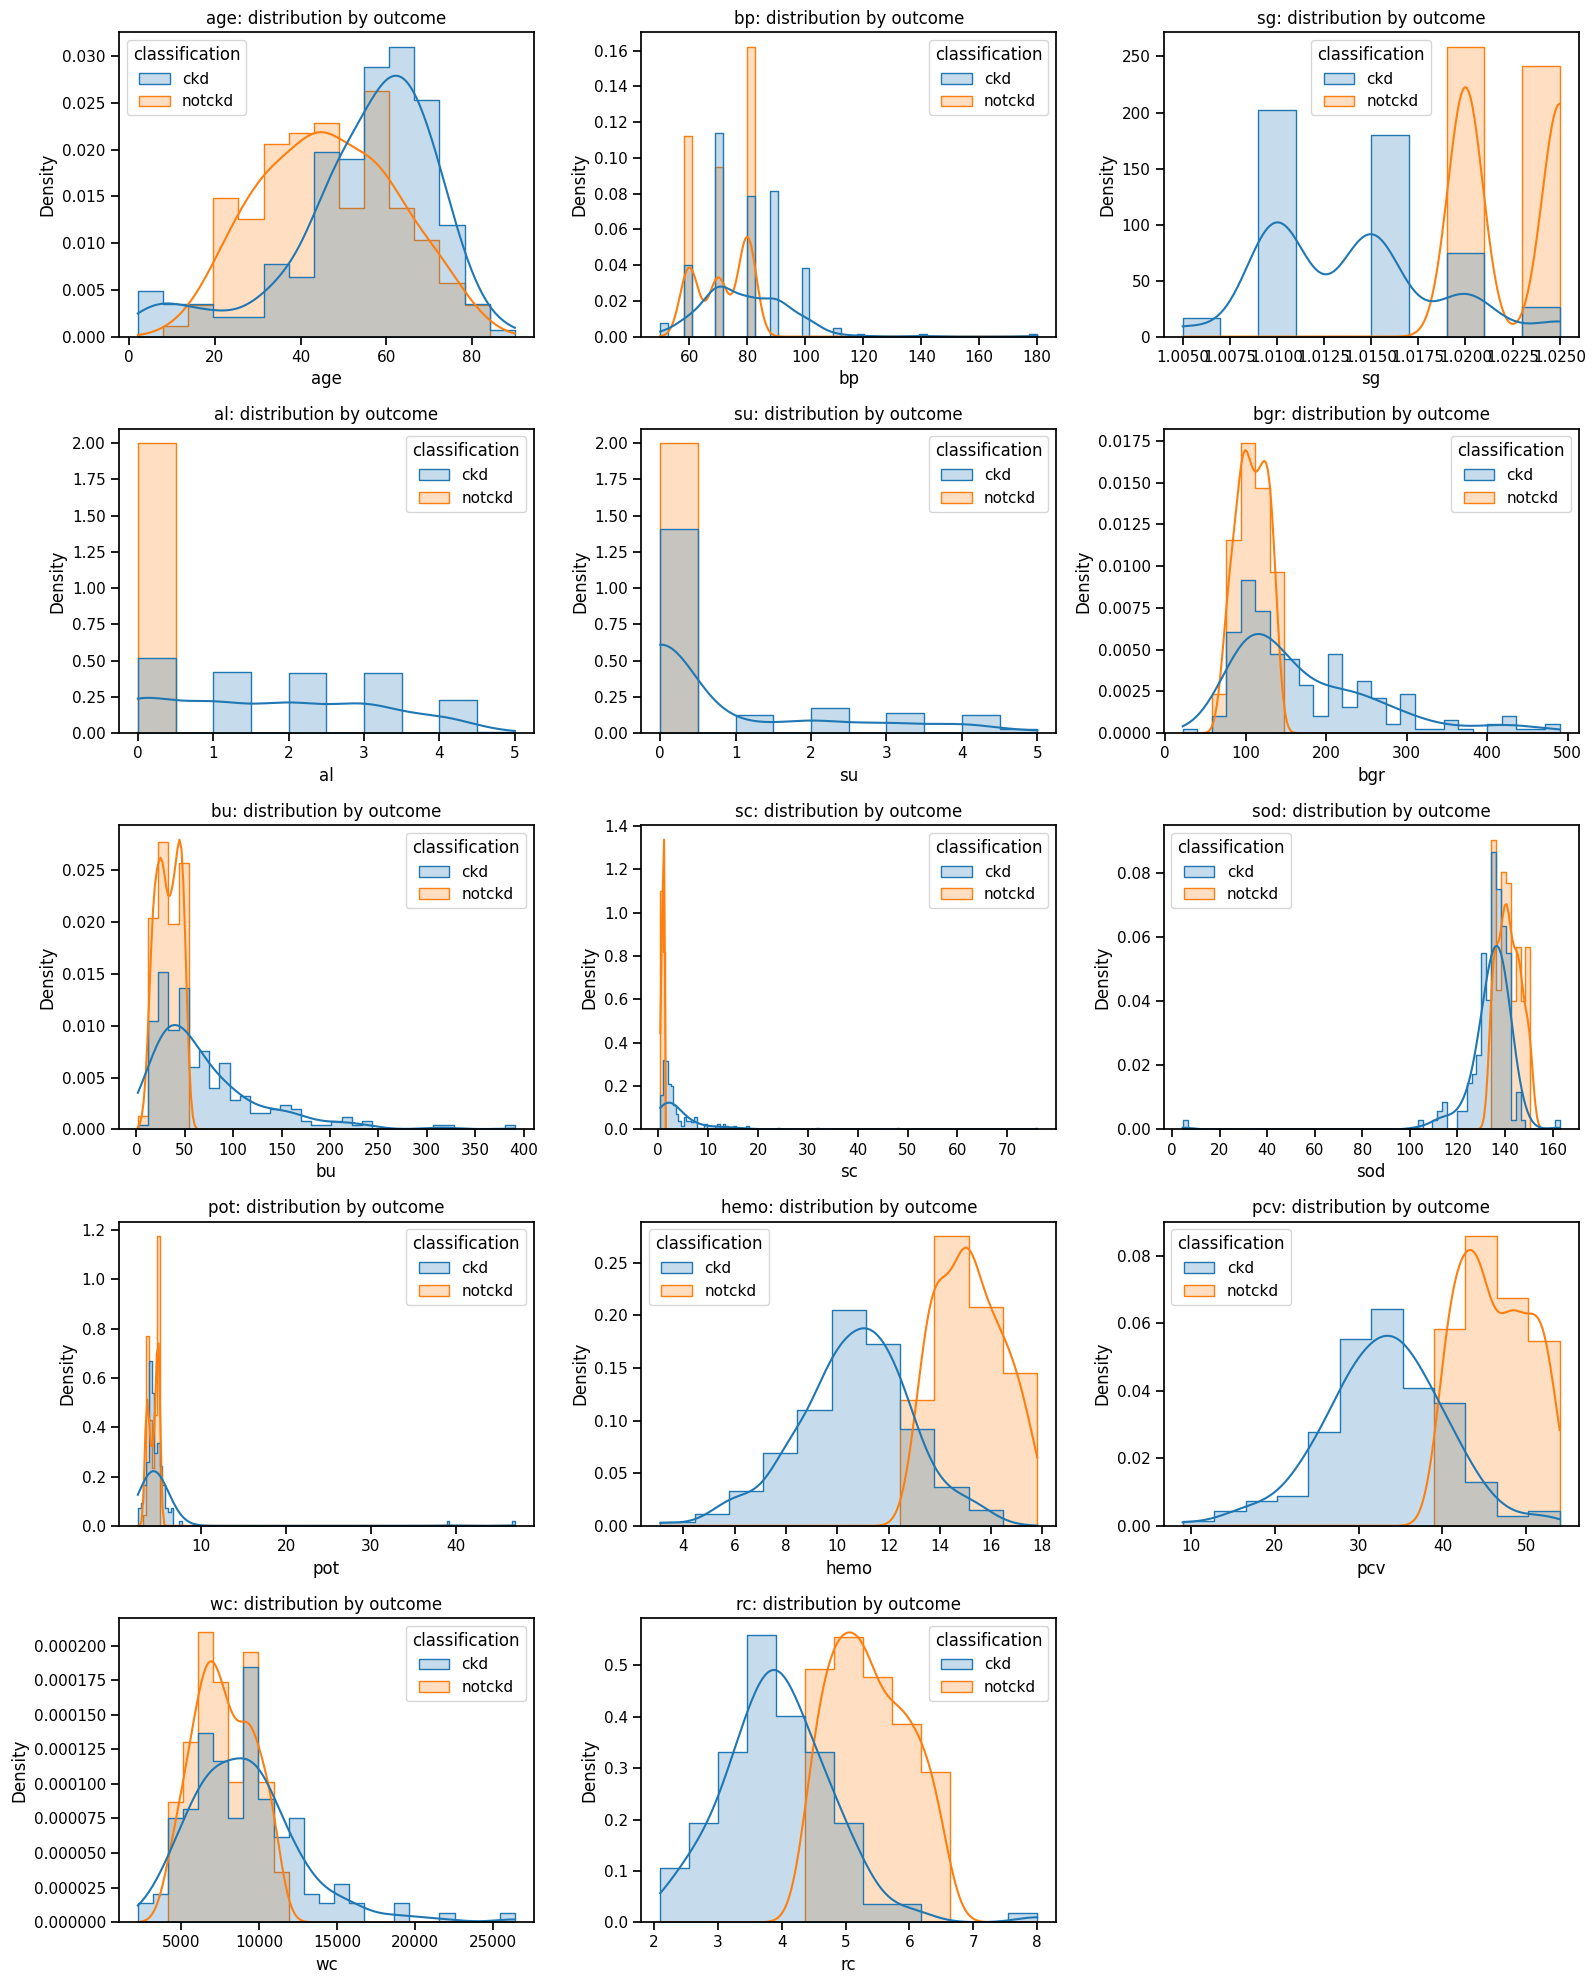

In [17]:
# Numerical distributions
n = len(numeric_cols)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4*nrows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, numeric_cols):
    sns.histplot(
        data=df,
        x=col,
        hue=target_col,
        kde=True,
        element="step",
        stat="density",
        common_norm=False,
        ax=ax
    )
    ax.set_title(f"{col}: distribution by outcome")

for ax in axes[len(numeric_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig(FIG_DIR / "numeric_distributions_by_target.png", dpi=180)
plt.show()

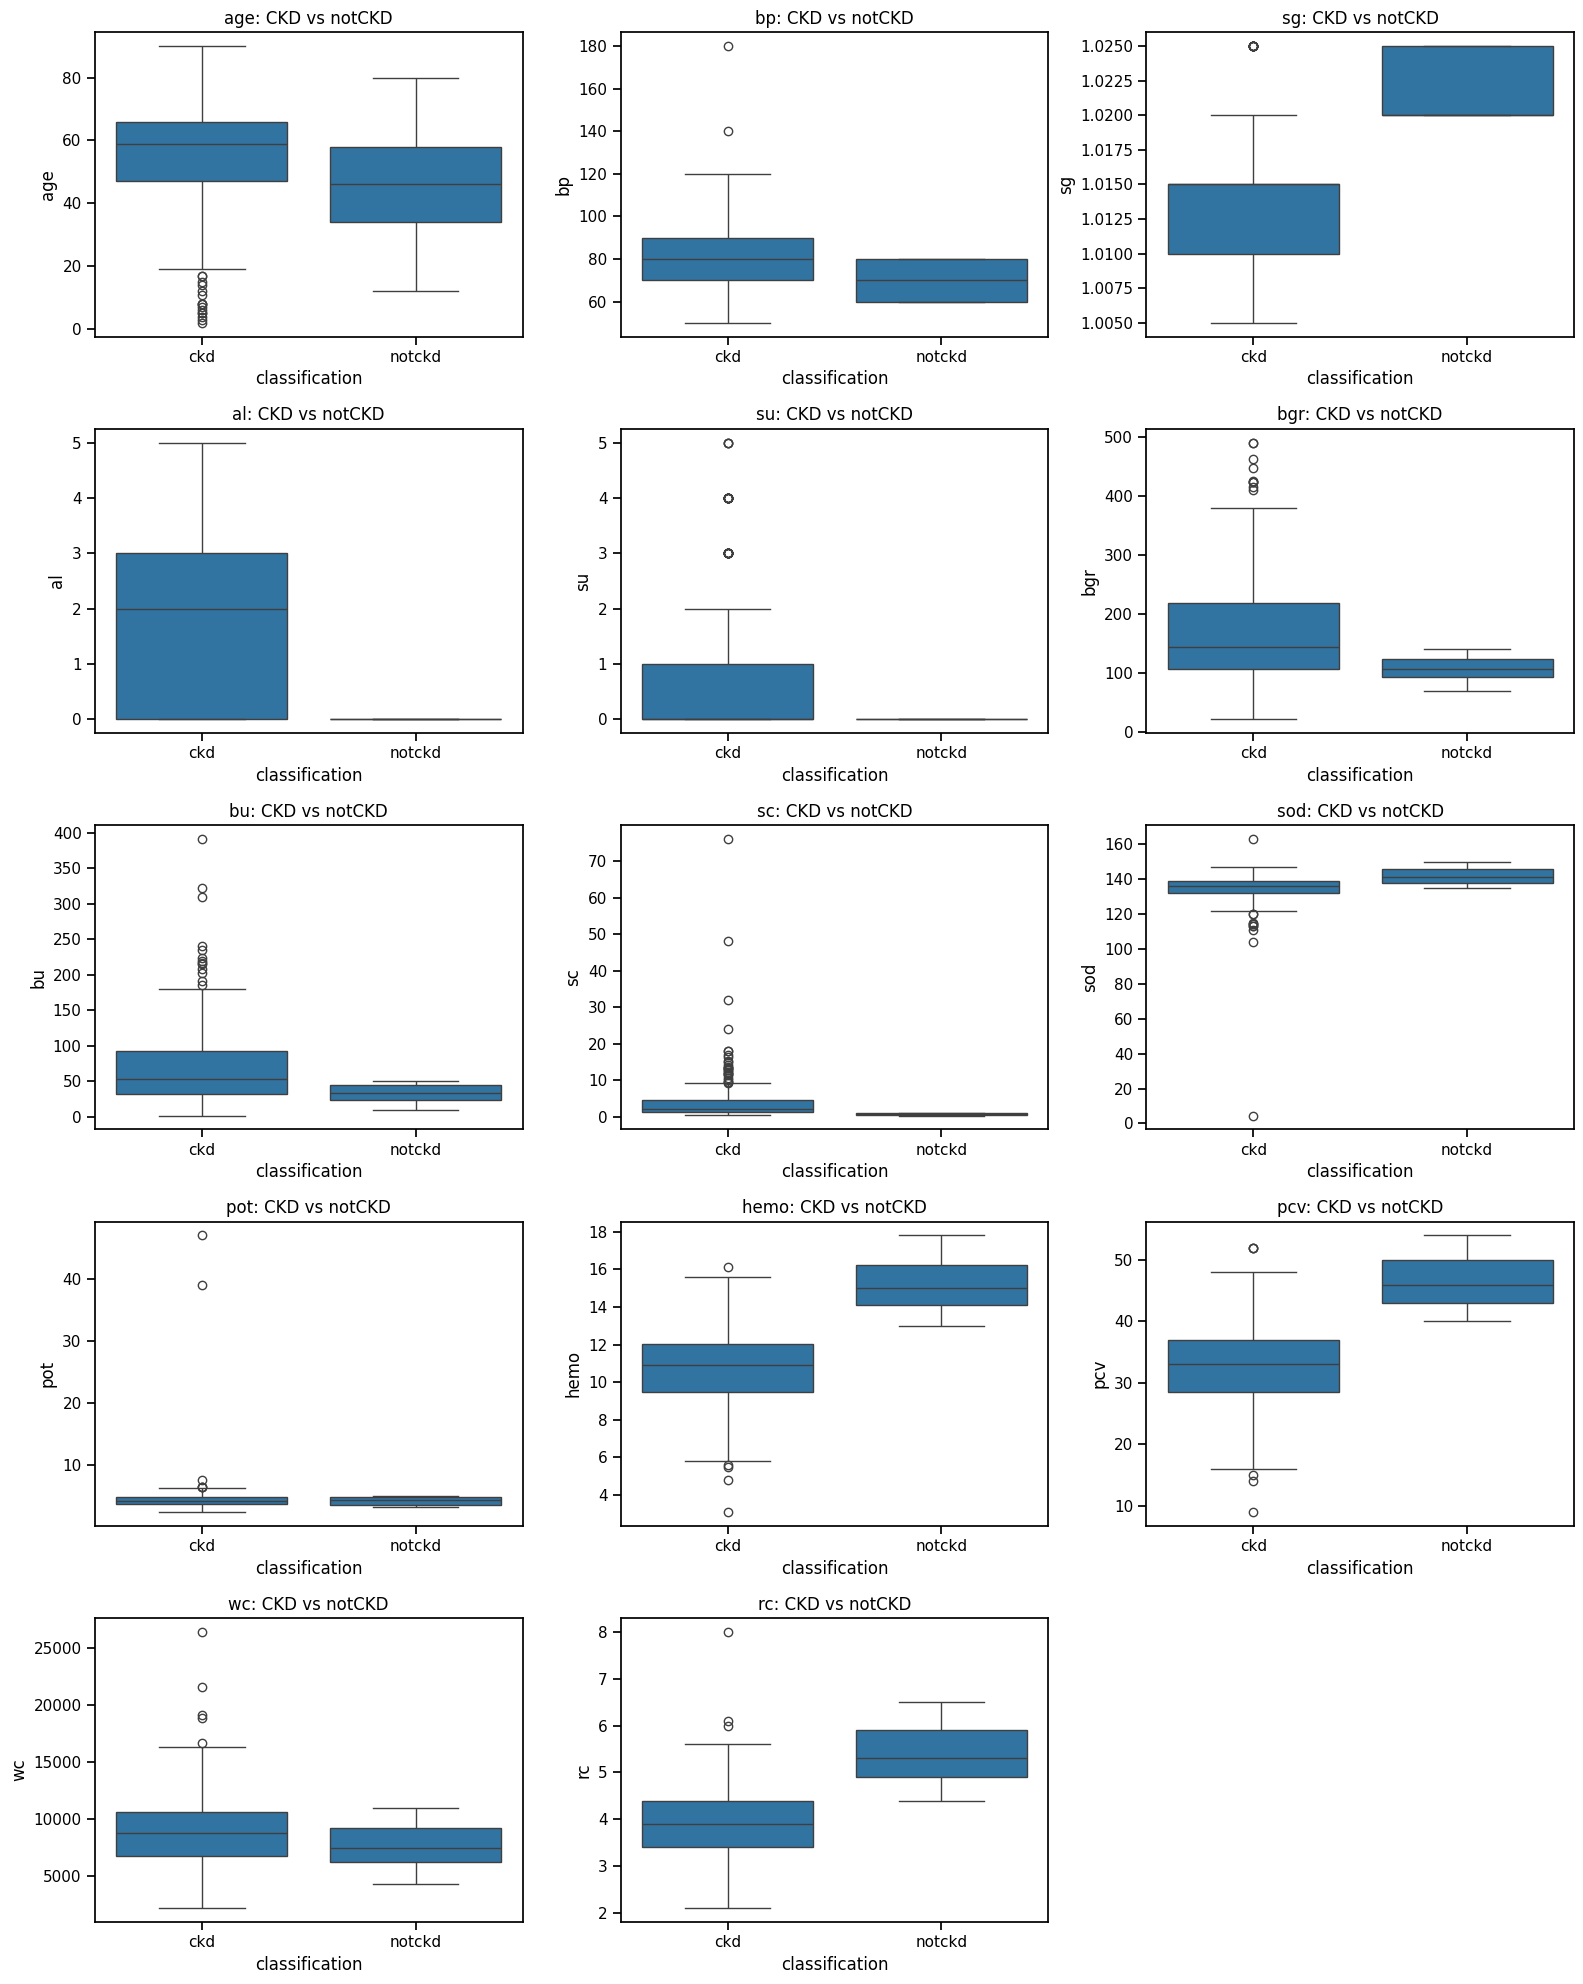

In [18]:
# Boxplots for numerical features by target
n = len(numeric_cols)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4*nrows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=df, x=target_col, y=col, ax=ax)
    ax.set_title(f"{col}: CKD vs notCKD")

for ax in axes[len(numeric_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig(FIG_DIR / "numeric_boxplots_by_target.png", dpi=180)
plt.show()

## 9. Categorical Distributions

,feature,level,count,percent
0,rbc,normal,201,50.2500
1,rbc,<NA>,152,38.0000
2,rbc,abnormal,47,11.7500
3,pc,normal,259,64.7500
4,pc,abnormal,76,19.0000
5,pc,<NA>,65,16.2500
6,pcc,notpresent,354,88.5000
7,pcc,present,42,10.5000
8,pcc,<NA>,4,1.0000
9,ba,notpresent,374,93.5000


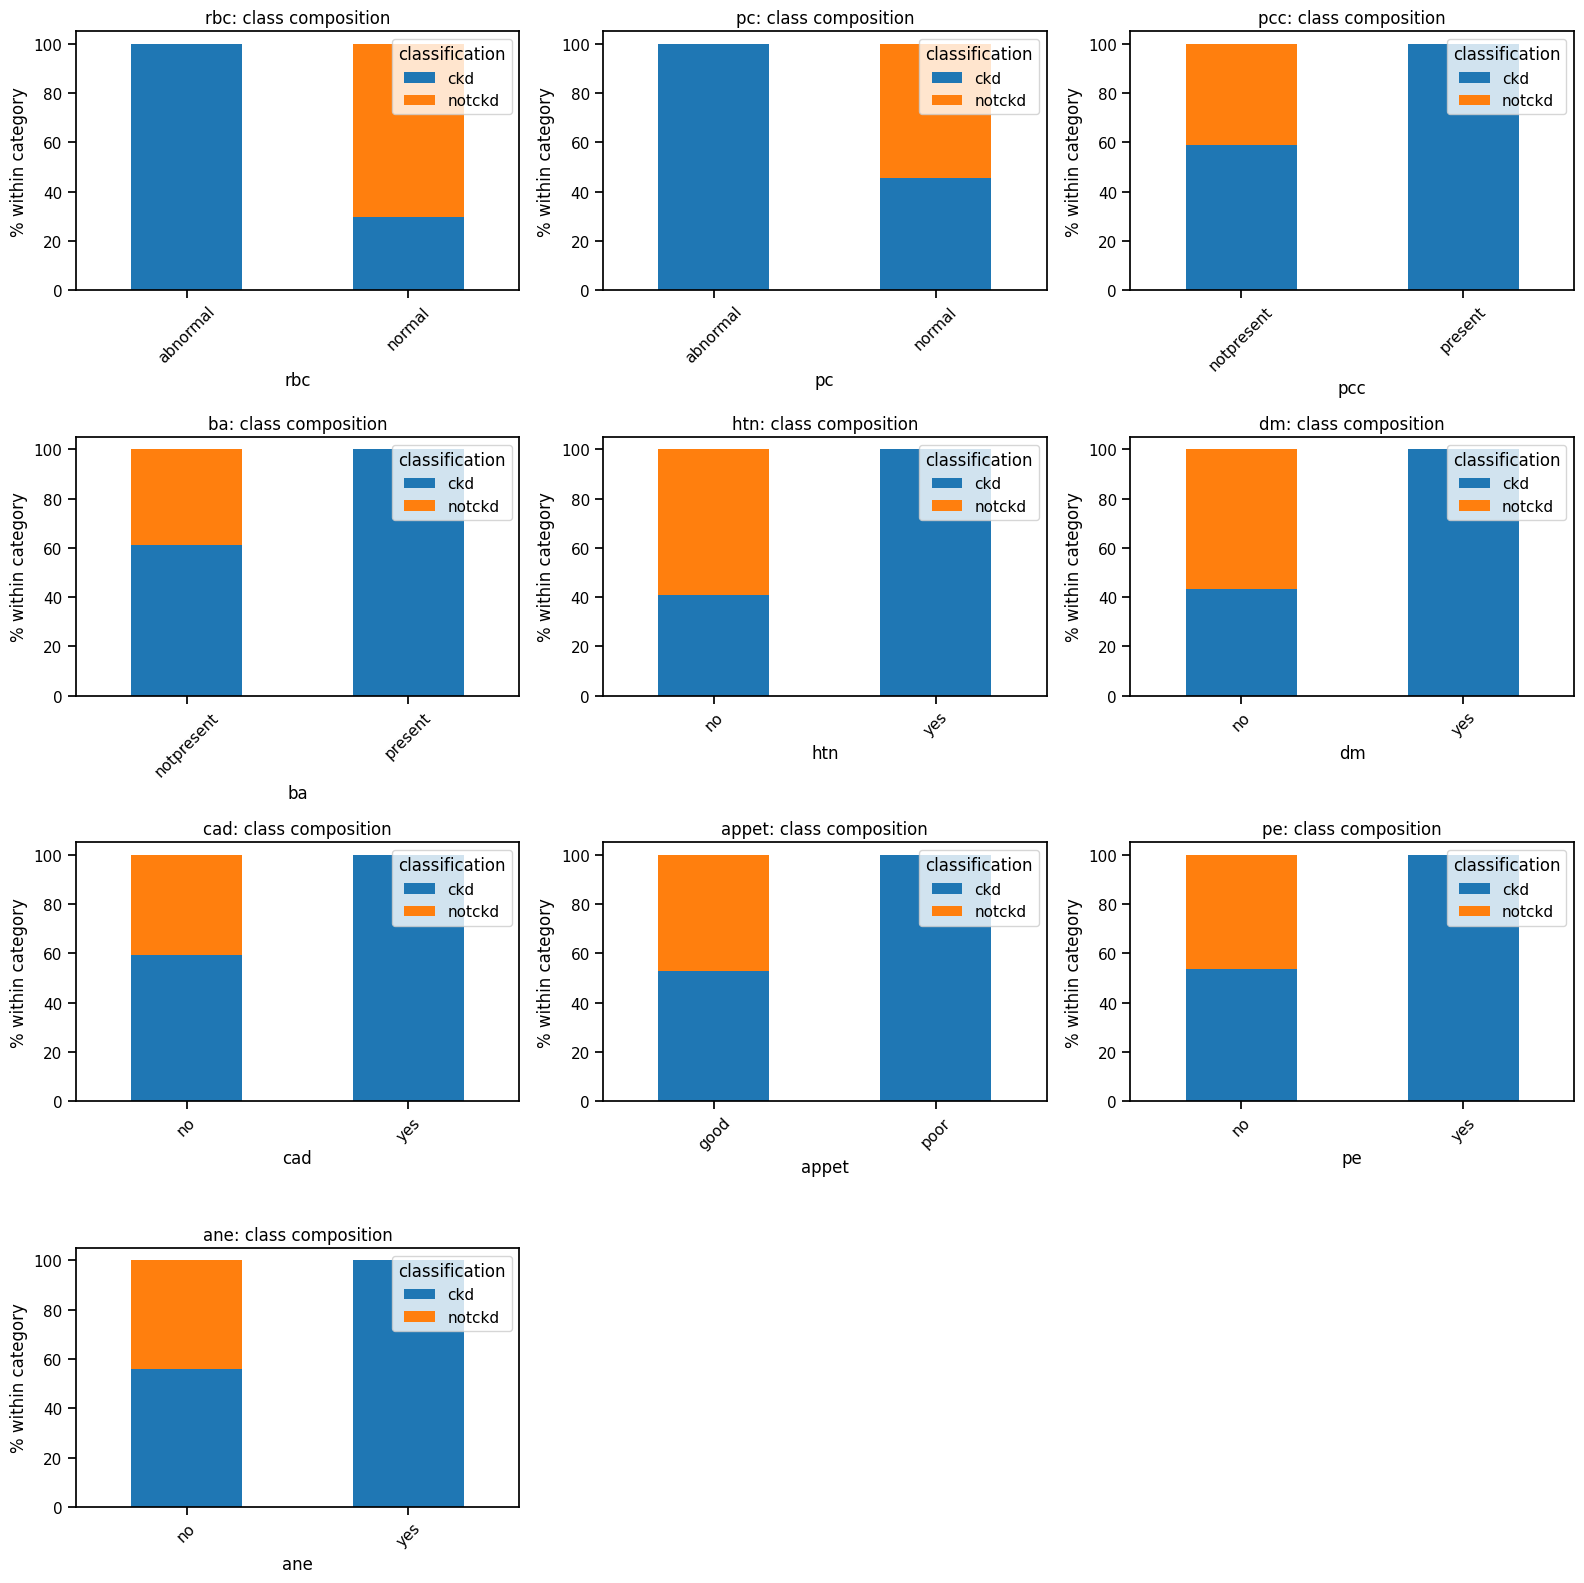

In [19]:
# ============================================================
# 9. CATEGORICAL SUMMARY
# ============================================================

categorical_summary_rows = []

for col in categorical_cols:
    vc = df[col].value_counts(dropna=False)
    for level, count in vc.items():
        categorical_summary_rows.append({
            "feature": col,
            "level": level,
            "count": int(count),
            "percent": 100 * count / len(df)
        })

categorical_summary = pd.DataFrame(categorical_summary_rows)
display(categorical_summary)
categorical_summary.to_csv(OUTPUT_DIR / "categorical_distribution.csv", index=False)

# Plots
if categorical_cols:
    n = len(categorical_cols)
    ncols = 3
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4*nrows))
    axes = np.array(axes).reshape(-1)

    for ax, col in zip(axes, categorical_cols):
        temp = (
            pd.crosstab(df[col], df[target_col], normalize="index") * 100
        )
        temp.plot(kind="bar", stacked=True, ax=ax)
        ax.set_title(f"{col}: class composition")
        ax.set_ylabel("% within category")
        ax.tick_params(axis="x", rotation=45)

    for ax in axes[len(categorical_cols):]:
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(FIG_DIR / "categorical_target_stacked.png", dpi=180)
    plt.show()

## 10. Outlier Analysis

We use **two statistical screens**:

1. IQR rule
2. robust modified z-score using MAD

These are *flags for investigation*, not deletion rules.

Clinically plausible severe CKD observations should generally be retained.

In [20]:
# ============================================================
# 10. OUTLIER ANALYSIS
# ============================================================

outlier_rows = []

for col in numeric_cols:
    s = df[col]

    valid = s.dropna()
    if len(valid) < 5:
        continue

    q1 = valid.quantile(0.25)
    q3 = valid.quantile(0.75)
    iqr = q3 - q1
    iqr_low = q1 - 1.5 * iqr
    iqr_high = q3 + 1.5 * iqr
    iqr_flag = s.notna() & ((s < iqr_low) | (s > iqr_high))

    median = valid.median()
    mad = np.median(np.abs(valid - median))
    if mad > 0:
        modified_z = 0.6745 * (s - median) / mad
        mad_flag = s.notna() & (np.abs(modified_z) > 3.5)
    else:
        modified_z = pd.Series(np.nan, index=s.index)
        mad_flag = pd.Series(False, index=s.index)

    outlier_rows.append({
        "feature": col,
        "iqr_low": iqr_low,
        "iqr_high": iqr_high,
        "iqr_outlier_n": int(iqr_flag.sum()),
        "iqr_outlier_pct": 100 * iqr_flag.mean(),
        "mad_outlier_n": int(mad_flag.sum()),
        "mad_outlier_pct": 100 * mad_flag.mean(),
        "median": median,
        "mad": mad
    })

outlier_summary = pd.DataFrame(outlier_rows).sort_values(
    "iqr_outlier_pct", ascending=False
)

display(outlier_summary)
outlier_summary.to_csv(OUTPUT_DIR / "outlier_summary.csv", index=False)

,feature,iqr_low,iqr_high,iqr_outlier_n,iqr_outlier_pct,mad_outlier_n,mad_outlier_pct,median,mad
4,su,0.0000,0.0000,61,15.2500,0,0.0000,0.0000,0.0000
7,sc,-1.9500,5.6500,51,12.7500,60,15.0000,1.3000,0.6000
6,bu,-31.5000,124.5000,38,9.5000,35,8.7500,42.0000,16.0000
1,bp,55.0000,95.0000,36,9.0000,2,0.5000,80.0000,10.0000
5,bgr,3.0000,259.0000,34,8.5000,40,10.0000,121.0000,25.0000
8,sod,124.5000,152.5000,16,4.0000,13,3.2500,138.0000,3.0000
0,age,8.2500,98.2500,10,2.5000,2,0.5000,55.0000,10.0000
12,wc,"1,550.0000","14,750.0000",10,2.5000,4,1.0000,"8,000.0000","1,700.0000"
9,pot,2.1500,6.5500,4,1.0000,3,0.7500,4.4000,0.5000
10,hemo,3.2500,22.0500,1,0.2500,0,0.0000,12.6500,2.3500


In [21]:
# Outlier counts by outcome
outlier_by_target = []

for col in numeric_cols:
    s = df[col]
    valid = s.dropna()
    if len(valid) < 5:
        continue

    q1, q3 = valid.quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
    flag = s.notna() & ((s < low) | (s > high))

    temp = pd.DataFrame({
        "target": df[target_col],
        "outlier": flag.astype(int)
    }).dropna(subset=["target"])

    summary = temp.groupby("target")["outlier"].agg(["sum", "count", "mean"])

    for cls, row in summary.iterrows():
        outlier_by_target.append({
            "feature": col,
            "class": cls,
            "outlier_n": int(row["sum"]),
            "class_n": int(row["count"]),
            "outlier_pct": 100 * row["mean"]
        })

outlier_by_target = pd.DataFrame(outlier_by_target)
display(outlier_by_target)
outlier_by_target.to_csv(OUTPUT_DIR / "outliers_by_target.csv", index=False)

,feature,class,outlier_n,class_n,outlier_pct
0,age,ckd,10,250,4.0000
1,age,notckd,0,150,0.0000
2,bp,ckd,36,250,14.4000
3,bp,notckd,0,150,0.0000
4,sg,ckd,0,250,0.0000
5,sg,notckd,0,150,0.0000
6,al,ckd,0,250,0.0000
7,al,notckd,0,150,0.0000
8,su,ckd,61,250,24.4000
9,su,notckd,0,150,0.0000


## 11. Numerical Feature–Target Relationships

For each numerical predictor we compute:

- CKD and non-CKD sample sizes
- medians and means
- Welch t-test
- Mann–Whitney U test
- rank-biserial effect size
- bootstrap 95% CI for the median difference
- Benjamini–Hochberg FDR correction

The effect size and CI are more informative than p-values alone.

In [22]:
# ============================================================
# 11. NUMERIC FEATURE–TARGET TESTS
# ============================================================

def bootstrap_median_diff_ci(x1, x0, n_boot=1000, ci=95, seed=42):
    rng = np.random.default_rng(seed)
    x1 = np.asarray(x1, dtype=float)
    x0 = np.asarray(x0, dtype=float)

    diffs = np.empty(n_boot)
    for i in range(n_boot):
        b1 = rng.choice(x1, size=len(x1), replace=True)
        b0 = rng.choice(x0, size=len(x0), replace=True)
        diffs[i] = np.median(b1) - np.median(b0)

    alpha = (100 - ci) / 2
    return np.percentile(diffs, alpha), np.percentile(diffs, 100-alpha)

numeric_target_results = []

for col in numeric_cols:
    temp = df[[col, target_col]].dropna()
    g1 = temp.loc[temp[target_col] == "ckd", col].astype(float).values
    g0 = temp.loc[temp[target_col] == "notckd", col].astype(float).values

    if len(g1) < 2 or len(g0) < 2:
        continue

    # Welch t-test
    t_stat, t_p = ttest_ind(g1, g0, equal_var=False, nan_policy="omit")

    # Mann–Whitney
    u_stat, u_p = mannwhitneyu(g1, g0, alternative="two-sided")

    # Rank-biserial effect size; sign depends on CKD-vs-notCKD ordering
    rbc = (2*u_stat)/(len(g1)*len(g0)) - 1

    ci_low, ci_high = bootstrap_median_diff_ci(
        g1, g0, n_boot=1000, seed=RANDOM_STATE
    )

    numeric_target_results.append({
        "feature": col,
        "n_ckd": len(g1),
        "n_notckd": len(g0),
        "mean_ckd": np.mean(g1),
        "mean_notckd": np.mean(g0),
        "median_ckd": np.median(g1),
        "median_notckd": np.median(g0),
        "median_difference_ckd_minus_notckd": np.median(g1) - np.median(g0),
        "median_diff_95ci_low": ci_low,
        "median_diff_95ci_high": ci_high,
        "welch_t_p": t_p,
        "mannwhitney_U": u_stat,
        "mannwhitney_p": u_p,
        "rank_biserial_effect": rbc
    })

numeric_target_results = pd.DataFrame(numeric_target_results)

if len(numeric_target_results):
    numeric_target_results["mannwhitney_p_fdr_bh"] = multipletests(
        numeric_target_results["mannwhitney_p"],
        method="fdr_bh"
    )[1]

    numeric_target_results["fdr_significant_0.05"] = (
        numeric_target_results["mannwhitney_p_fdr_bh"] < 0.05
    )

    numeric_target_results = numeric_target_results.sort_values(
        "mannwhitney_p_fdr_bh"
    )

display(numeric_target_results)
numeric_target_results.to_csv(
    OUTPUT_DIR / "numeric_feature_target_tests.csv",
    index=False
)

,feature,n_ckd,n_notckd,mean_ckd,mean_notckd,median_ckd,median_notckd,median_difference_ckd_minus_notckd,median_diff_95ci_low,median_diff_95ci_high,welch_t_p,mannwhitney_U,mannwhitney_p,rank_biserial_effect,mannwhitney_p_fdr_bh,fdr_significant_0.05
10,hemo,204,144,10.6475,15.1882,10.9000,15.0000,-4.1000,-4.7500,-3.9000,0.0000,917.5000,0.0000,-0.9375,0.0000,True
11,pcv,183,146,32.9399,46.3356,33.0000,46.0000,-13.0000,-15.0000,-11.0000,0.0000,"1,270.5000",0.0000,-0.9049,0.0000,True
2,sg,208,145,1.0139,1.0224,1.0150,1.0200,-0.0050,-0.0100,-0.0050,0.0000,"2,372.5000",0.0000,-0.8427,0.0000,True
7,sc,238,145,4.4149,0.8690,2.2500,0.9000,1.3500,1.1987,1.7500,0.0000,"31,841.5000",0.0000,0.8453,0.0000,True
3,al,209,145,1.7225,0.0000,2.0000,0.0000,2.0000,1.0000,2.0000,0.0000,"26,390.0000",0.0000,0.7416,0.0000,True
13,rc,126,143,3.9452,5.3790,3.9000,5.3000,-1.4000,-1.6000,-1.2000,0.0000,"1,363.5000",0.0000,-0.8487,0.0000,True
8,sod,168,145,133.9018,141.7310,136.0000,141.0000,-5.0000,-7.0000,-4.0000,0.0000,"4,777.0000",0.0000,-0.6078,0.0000,True
6,bu,237,144,72.3890,32.7986,53.0000,33.0000,20.0000,14.5000,27.0000,0.0000,"25,641.5000",0.0000,0.5027,0.0000,True
5,bgr,212,144,175.4198,107.7222,143.5000,107.5000,36.0000,22.9875,52.0000,0.0000,"22,813.0000",0.0000,0.4946,0.0000,True
4,su,206,145,0.7670,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,"19,357.5000",0.0000,0.2961,0.0000,True


## 12. Categorical Feature–Target Relationships

We use χ² or Fisher's exact test where appropriate, Cramér's V, and for 2×2 tables an odds ratio with a 95% CI.

The odds ratio is descriptive association here; it is **not** a causal estimate.

In [23]:
# ============================================================
# 12. CATEGORICAL FEATURE–TARGET TESTS
# ============================================================

def cramers_v_from_table(table):
    arr = np.asarray(table)
    if arr.size == 0:
        return np.nan
    chi2 = chi2_contingency(arr, correction=False)[0]
    n = arr.sum()
    r, k = arr.shape
    denom = min(k-1, r-1)
    if n == 0 or denom <= 0:
        return np.nan
    return np.sqrt(chi2 / (n * denom))

def odds_ratio_ci_2x2(table):
    # Haldane–Anscombe correction if any zero cell
    arr = np.asarray(table, dtype=float)
    if arr.shape != (2,2):
        return np.nan, np.nan, np.nan

    if (arr == 0).any():
        arr = arr + 0.5

    a, b = arr[0,0], arr[0,1]
    c, d = arr[1,0], arr[1,1]

    OR = (a*d)/(b*c)
    se = np.sqrt(1/a + 1/b + 1/c + 1/d)
    log_or = np.log(OR)
    low = np.exp(log_or - 1.96*se)
    high = np.exp(log_or + 1.96*se)
    return OR, low, high

categorical_target_results = []

for col in categorical_cols:
    temp = df[[col, target_col]].dropna()
    table = pd.crosstab(temp[col], temp[target_col])

    if table.shape[0] < 2 or table.shape[1] < 2:
        continue

    chi2, p_chi, dof, expected = chi2_contingency(table)
    use_fisher = table.shape == (2,2) and (expected < 5).any()

    if use_fisher:
        _, p = fisher_exact(table.values)
        test = "Fisher exact"
    else:
        p = p_chi
        test = "Chi-square"

    cv = cramers_v_from_table(table)

    OR, OR_low, OR_high = odds_ratio_ci_2x2(table.values)

    categorical_target_results.append({
        "feature": col,
        "test": test,
        "p_value": p,
        "cramers_v": cv,
        "odds_ratio_if_2x2": OR,
        "or_95ci_low": OR_low,
        "or_95ci_high": OR_high,
        "levels": "; ".join(map(str, table.index.tolist()))
    })

categorical_target_results = pd.DataFrame(categorical_target_results)

if len(categorical_target_results):
    categorical_target_results["p_fdr_bh"] = multipletests(
        categorical_target_results["p_value"],
        method="fdr_bh"
    )[1]
    categorical_target_results["fdr_significant_0.05"] = (
        categorical_target_results["p_fdr_bh"] < 0.05
    )
    categorical_target_results = categorical_target_results.sort_values(
        "p_fdr_bh"
    )

display(categorical_target_results)
categorical_target_results.to_csv(
    OUTPUT_DIR / "categorical_feature_target_tests.csv",
    index=False
)

,feature,test,p_value,cramers_v,odds_ratio_if_2x2,or_95ci_low,or_95ci_high,levels,p_fdr_bh,fdr_significant_0.05
4,htn,Chi-square,0.0000,0.5888,0.0024,0.0001,0.0384,no; yes,0.0000,True
5,dm,Chi-square,0.0000,0.5574,0.0028,0.0002,0.0451,no; yes,0.0000,True
0,rbc,Chi-square,0.0000,0.5551,222.1901,13.4759,"3,663.4515",abnormal; normal,0.0000,True
1,pc,Chi-square,0.0000,0.4618,182.6962,11.2036,"2,979.2190",abnormal; normal,0.0000,True
7,appet,Chi-square,0.0000,0.3926,0.0068,0.0004,0.1111,good; poor,0.0000,True
8,pe,Chi-square,0.0000,0.3745,0.0076,0.0005,0.1241,no; yes,0.0000,True
9,ane,Chi-square,0.0000,0.3248,0.0105,0.0006,0.1717,no; yes,0.0000,True
2,pcc,Chi-square,0.0000,0.2632,0.0167,0.0010,0.2743,notpresent; present,0.0000,True
6,cad,Chi-square,0.0000,0.2352,0.0211,0.0013,0.3473,no; yes,0.0000,True
3,ba,Chi-square,0.0005,0.1853,0.0347,0.0021,0.5758,notpresent; present,0.0005,True


## 13. Correlation, Redundancy, and Multicollinearity

Because the numerical variables are not necessarily normally distributed, the primary numerical correlation matrix uses **Spearman correlation**.

We also list highly correlated pairs and compute exploratory VIFs after median imputation.

> VIF is mainly relevant for coefficient interpretation in linear/logistic regression. It is not an automatic deletion rule for tree models.

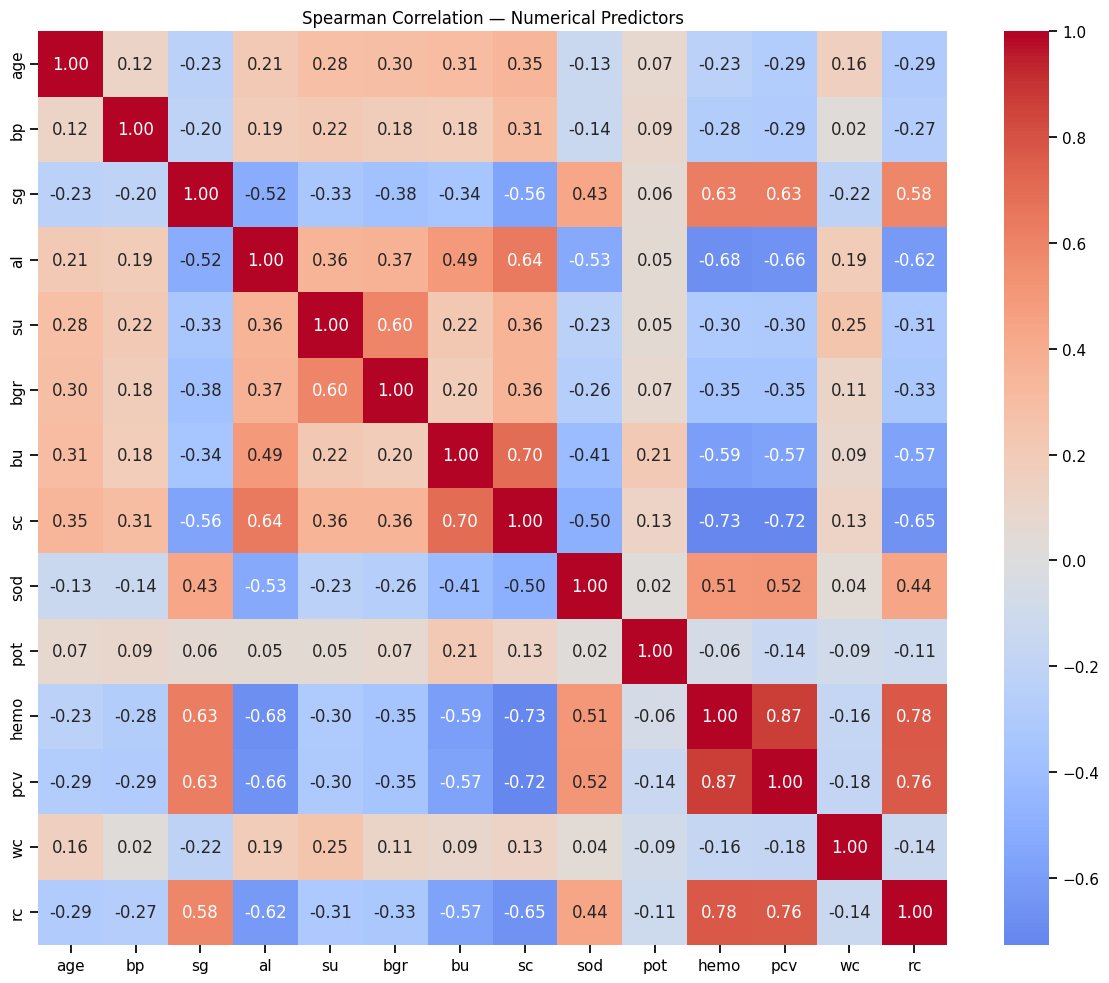

,feature_1,feature_2,spearman_rho,abs_rho
0,hemo,pcv,0.8678,0.8678


In [24]:
# ============================================================
# 13A. SPEARMAN CORRELATION
# ============================================================

spearman_corr = df[numeric_cols].corr(method="spearman")

plt.figure(figsize=(12,10))
sns.heatmap(
    spearman_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=False
)
plt.title("Spearman Correlation — Numerical Predictors")
plt.tight_layout()
plt.savefig(FIG_DIR / "spearman_correlation_heatmap.png", dpi=180)
plt.show()

spearman_corr.to_csv(OUTPUT_DIR / "spearman_correlation_matrix.csv")

# Redundant/high-correlation pairs
HIGH_CORR_THRESHOLD = 0.80

redundant_pairs = []
for a, b in combinations(numeric_cols, 2):
    rho = spearman_corr.loc[a, b]
    if pd.notna(rho) and abs(rho) >= HIGH_CORR_THRESHOLD:
        redundant_pairs.append({
            "feature_1": a,
            "feature_2": b,
            "spearman_rho": rho,
            "abs_rho": abs(rho)
        })

redundant_pairs = pd.DataFrame(redundant_pairs)
if len(redundant_pairs):
    redundant_pairs = redundant_pairs.sort_values("abs_rho", ascending=False)

display(redundant_pairs if len(redundant_pairs) else pd.DataFrame({"message":["No pairs ≥ threshold"]}))
redundant_pairs.to_csv(OUTPUT_DIR / "high_correlation_pairs.csv", index=False)

In [25]:
# ============================================================
# 13B. NUMERIC VIF
# ============================================================

vif_df = pd.DataFrame()

if len(numeric_cols) >= 2:
    X_vif = df[numeric_cols].copy()
    X_vif = X_vif.apply(pd.to_numeric, errors="coerce")
    X_vif = X_vif.fillna(X_vif.median())

    # Drop zero-variance numeric variables before VIF
    nonconstant_vif_cols = [
        c for c in X_vif.columns if X_vif[c].nunique() > 1
    ]
    X_vif = X_vif[nonconstant_vif_cols]

    if X_vif.shape[1] >= 2:
        vif_values = []
        for i, col in enumerate(X_vif.columns):
            try:
                v = variance_inflation_factor(X_vif.values, i)
            except Exception:
                v = np.nan
            vif_values.append(v)

        vif_df = pd.DataFrame({
            "feature": X_vif.columns,
            "VIF": vif_values
        }).sort_values("VIF", ascending=False)

display(vif_df)
vif_df.to_csv(OUTPUT_DIR / "numeric_vif.csv", index=False)

,feature,VIF
0,age,NaN
1,bp,NaN
2,sg,NaN
3,al,NaN
4,su,NaN
5,bgr,NaN
6,bu,NaN
7,sc,NaN
8,sod,NaN
9,pot,NaN


## 14. Categorical–Categorical Redundancy: Cramér's V Matrix

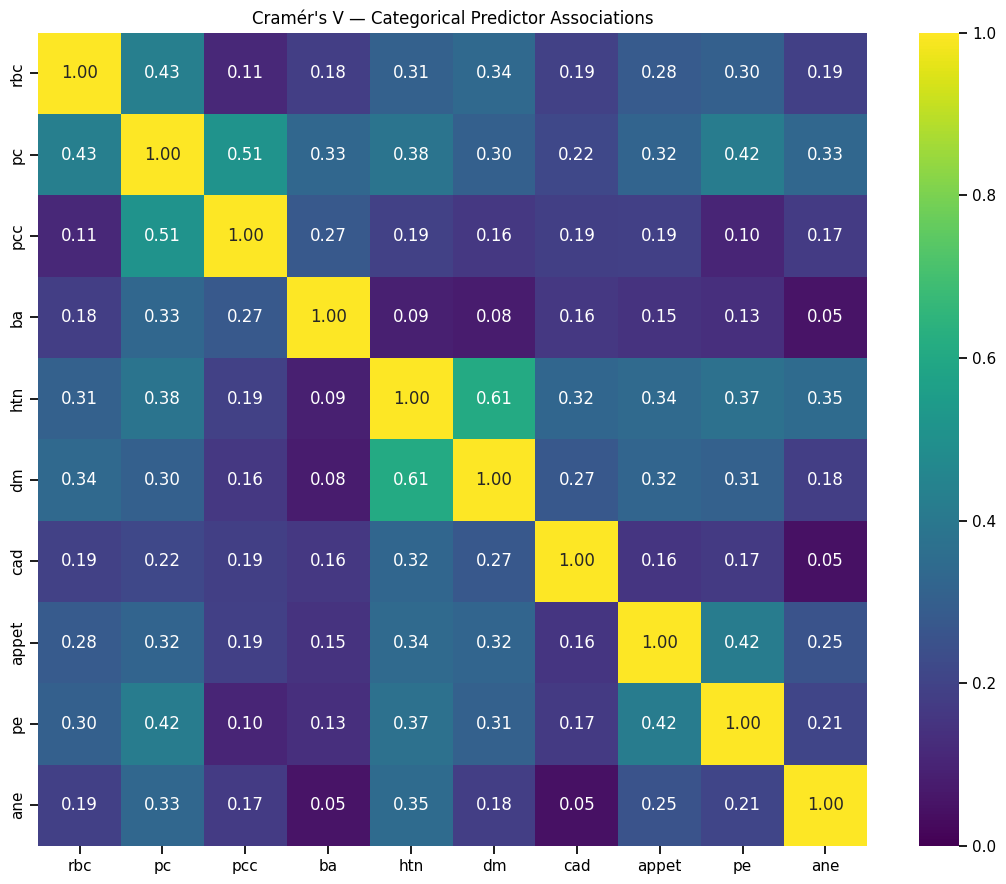

In [26]:
# ============================================================
# 14. CRAMER'S V MATRIX FOR CATEGORICAL FEATURES
# ============================================================

def cramers_v_series(x, y):
    temp = pd.DataFrame({"x": x, "y": y}).dropna()
    table = pd.crosstab(temp["x"], temp["y"])
    if table.shape[0] < 2 or table.shape[1] < 2:
        return np.nan
    return cramers_v_from_table(table.values)

if categorical_cols:
    cv_matrix = pd.DataFrame(
        np.eye(len(categorical_cols)),
        index=categorical_cols,
        columns=categorical_cols
    )

    for a, b in combinations(categorical_cols, 2):
        cv = cramers_v_series(df[a], df[b])
        cv_matrix.loc[a, b] = cv
        cv_matrix.loc[b, a] = cv

    plt.figure(figsize=(11,9))
    sns.heatmap(cv_matrix, annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=1)
    plt.title("Cramér's V — Categorical Predictor Associations")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "categorical_cramers_v_matrix.png", dpi=180)
    plt.show()

    cv_matrix.to_csv(OUTPUT_DIR / "categorical_cramers_v_matrix.csv")

## 15. Nonlinear Feature–Target Screening via Mutual Information

This is an **EDA-only nonlinear association screen**.

It is **not** valid to use this whole-dataset MI ranking as the final feature selector and then report cross-validation performance. Final feature selection must be re-fit inside each training fold.

,feature,mutual_information,treated_as_discrete
10,hemo,0.4570,False
11,pcv,0.4150,False
7,sc,0.3734,False
13,rc,0.3469,False
2,sg,0.3333,False
14,rbc,0.2698,True
8,sod,0.2533,False
3,al,0.2526,True
18,htn,0.2368,True
9,pot,0.2294,False


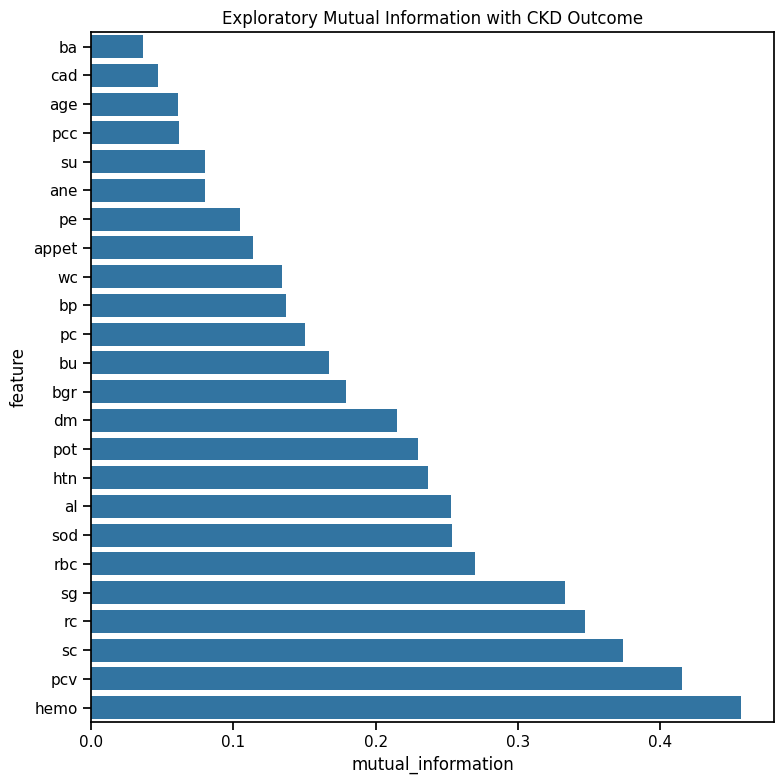

In [27]:
# ============================================================
# 15. MUTUAL INFORMATION — EXPLORATORY ONLY
# ============================================================

mi_data = df[model_predictors + [target_col]].copy()
mi_data = mi_data[mi_data[target_col].isin(["ckd", "notckd"])].copy()

y_mi = mi_data[target_col].map({"notckd": 0, "ckd": 1}).astype(int)

X_mi_parts = []
mi_feature_names = []
discrete_mask = []

# Numeric features: median imputation for EDA-only MI
for col in numeric_cols:
    s = pd.to_numeric(mi_data[col], errors="coerce")
    s = s.fillna(s.median())
    X_mi_parts.append(s.to_numpy().reshape(-1,1))
    mi_feature_names.append(col)

    # al/su/sg are discrete/ordinal-like in this dataset;
    # flag only al/su as discrete for MI.
    discrete_mask.append(col in ["al", "su"])

# Categorical features: factorize categories, preserving missing as its own code
for col in categorical_cols:
    s = mi_data[col].astype("string").fillna("__missing__")
    codes, uniques = pd.factorize(s)
    X_mi_parts.append(codes.reshape(-1,1))
    mi_feature_names.append(col)
    discrete_mask.append(True)

X_mi = np.hstack(X_mi_parts)

mi_scores = mutual_info_classif(
    X_mi,
    y_mi,
    discrete_features=np.array(discrete_mask),
    random_state=RANDOM_STATE
)

mi_results = pd.DataFrame({
    "feature": mi_feature_names,
    "mutual_information": mi_scores,
    "treated_as_discrete": discrete_mask
}).sort_values("mutual_information", ascending=False)

display(mi_results)
mi_results.to_csv(OUTPUT_DIR / "mutual_information_exploratory.csv", index=False)

plt.figure(figsize=(8,8))
sns.barplot(
    data=mi_results.sort_values("mutual_information"),
    x="mutual_information",
    y="feature"
)
plt.title("Exploratory Mutual Information with CKD Outcome")
plt.tight_layout()
plt.savefig(FIG_DIR / "mutual_information.png", dpi=180)
plt.show()

## 16. Leakage Audit

This section investigates:

- ID–target ordering/proxy leakage
- features with near-perfect univariate discrimination
- duplicated clinical rows
- presence/absence of time columns
- availability of patient/group identifiers

A high univariate AUC is not automatically leakage: serum creatinine, albumin, etc. may legitimately separate CKD. It is a **review flag** requiring clinical interpretation.

ID leakage audit
Raw ID AUC: 0.0
Oriented ID AUC: 1.0
Best threshold: {'acc': np.float64(1.0), 'threshold': 249.5, 'direction': 'id < threshold => CKD'}


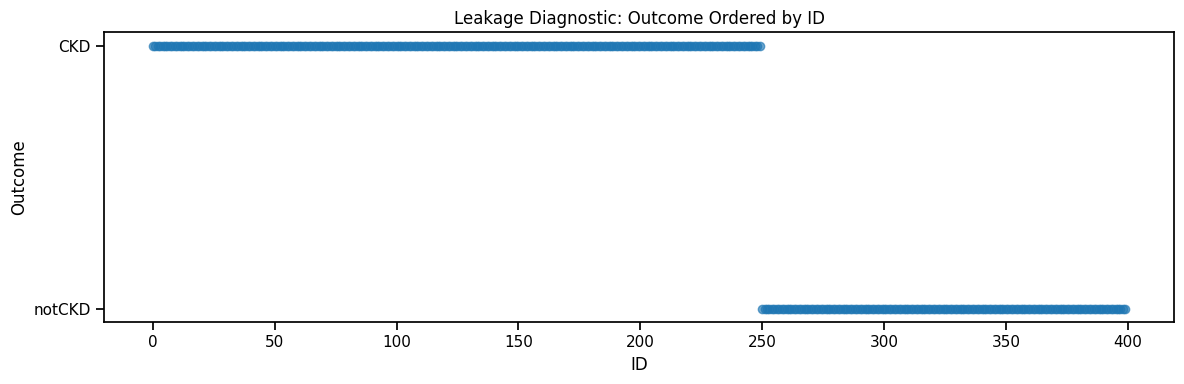

In [28]:
# ============================================================
# 16A. ID LEAKAGE AUDIT
# ============================================================

leakage_rows = []

if id_col and id_col in df.columns:
    temp = df[[id_col, target_col]].dropna()
    temp = temp[temp[target_col].isin(["ckd", "notckd"])].copy()
    y_id = temp[target_col].map({"notckd":0, "ckd":1}).astype(int)
    ids = pd.to_numeric(temp[id_col], errors="coerce")

    if ids.notna().all() and y_id.nunique() == 2:
        auc = roc_auc_score(y_id, ids)
        oriented_auc = max(auc, 1-auc)

        # Best one-threshold accuracy in either direction
        vals = np.sort(ids.unique())
        thresholds = (vals[:-1] + vals[1:]) / 2 if len(vals) > 1 else vals

        best = {"acc": -1, "threshold": np.nan, "direction": None}

        for t in thresholds:
            pred_high_ckd = (ids >= t).astype(int)
            pred_low_ckd = (ids < t).astype(int)

            for pred, direction in [
                (pred_high_ckd, "id >= threshold => CKD"),
                (pred_low_ckd, "id < threshold => CKD")
            ]:
                acc = (pred.values == y_id.values).mean()
                if acc > best["acc"]:
                    best = {
                        "acc": acc,
                        "threshold": float(t),
                        "direction": direction
                    }

        leakage_rows.append({
            "check": "ID univariate discrimination",
            "value": oriented_auc,
            "details": f"Oriented AUC={oriented_auc:.4f}"
        })
        leakage_rows.append({
            "check": "Best single ID threshold accuracy",
            "value": best["acc"],
            "details": f"{best['direction']} at {best['threshold']:.4f}"
        })

        print("ID leakage audit")
        print("Raw ID AUC:", auc)
        print("Oriented ID AUC:", oriented_auc)
        print("Best threshold:", best)

        # Plot outcome vs ID
        plot_temp = temp.sort_values(id_col).copy()
        plot_temp["target_binary"] = plot_temp[target_col].map({"notckd":0, "ckd":1})

        plt.figure(figsize=(12,4))
        plt.scatter(plot_temp[id_col], plot_temp["target_binary"], alpha=0.65)
        plt.yticks([0,1], ["notCKD","CKD"])
        plt.xlabel("ID")
        plt.ylabel("Outcome")
        plt.title("Leakage Diagnostic: Outcome Ordered by ID")
        plt.tight_layout()
        plt.savefig(FIG_DIR / "id_target_leakage.png", dpi=180)
        plt.show()

In [29]:
# ============================================================
# 16B. NUMERIC UNIVARIATE AUC FLAGS
# ============================================================

auc_rows = []

temp_y = df[target_col].map({"notckd":0, "ckd":1})

for col in numeric_cols:
    temp = pd.DataFrame({
        "x": pd.to_numeric(df[col], errors="coerce"),
        "y": temp_y
    }).dropna()

    if temp["y"].nunique() != 2 or temp["x"].nunique() < 2:
        continue

    # Median fill is unnecessary after dropna; AUC is descriptive only.
    auc = roc_auc_score(temp["y"], temp["x"])
    oriented_auc = max(auc, 1-auc)

    auc_rows.append({
        "feature": col,
        "raw_auc": auc,
        "oriented_auc": oriented_auc,
        "n_used": len(temp),
        "review_flag_auc_ge_0.95": oriented_auc >= 0.95
    })

univariate_auc = pd.DataFrame(auc_rows).sort_values(
    "oriented_auc", ascending=False
)

display(univariate_auc)
univariate_auc.to_csv(OUTPUT_DIR / "univariate_auc_leakage_review.csv", index=False)

# Time-column audit
time_like_cols = [
    c for c in df.columns
    if any(token in c.lower() for token in ["date", "time", "visit", "admission", "discharge"])
]

# Group/patient identifier audit
group_like_cols = [
    c for c in df.columns
    if any(token in c.lower() for token in ["patient", "subject", "person", "mrn", "encounter"])
]

leakage_rows.extend([
    {
        "check": "Duplicates excluding ID",
        "value": clean_dup_excluding_id,
        "details": "Potential repeated/duplicated clinical profiles; inspect if >0."
    },
    {
        "check": "Time-like columns detected",
        "value": len(time_like_cols),
        "details": str(time_like_cols)
    },
    {
        "check": "Patient/group identifier columns detected (excluding generic id)",
        "value": len(group_like_cols),
        "details": str(group_like_cols)
    }
])

leakage_audit = pd.DataFrame(leakage_rows)
display(leakage_audit)
leakage_audit.to_csv(OUTPUT_DIR / "leakage_audit.csv", index=False)

print("\nInterpretation:")
print("- A very high ID AUC/threshold accuracy indicates ID/order leakage.")
print("- Near-perfect clinical-feature AUCs require clinical review for label circularity/inclusion bias.")
print("- No time columns means temporal leakage cannot be fully assessed and prognostic claims are limited.")
print("- No repeated-patient identifier means patient-level grouping cannot be guaranteed beyond duplicate checks.")

,feature,raw_auc,oriented_auc,n_used,review_flag_auc_ge_0.95
10,hemo,0.0312,0.9688,348,True
11,pcv,0.0476,0.9524,329,True
13,rc,0.0757,0.9243,269,False
7,sc,0.9227,0.9227,383,False
2,sg,0.0787,0.9213,353,False
3,al,0.8708,0.8708,354,False
8,sod,0.1961,0.8039,313,False
6,bu,0.7513,0.7513,381,False
5,bgr,0.7473,0.7473,356,False
1,bp,0.6656,0.6656,388,False


,check,value,details
0,ID univariate discrimination,1.0000,Oriented AUC=1.0000
1,Best single ID threshold accuracy,1.0000,id < threshold => CKD at 249.5000
2,Duplicates excluding ID,0.0000,Potential repeated/duplicated clinical profile...
3,Time-like columns detected,0.0000,[]
4,Patient/group identifier columns detected (exc...,0.0000,[]



Interpretation:
- A very high ID AUC/threshold accuracy indicates ID/order leakage.
- Near-perfect clinical-feature AUCs require clinical review for label circularity/inclusion bias.
- No time columns means temporal leakage cannot be fully assessed and prognostic claims are limited.
- No repeated-patient identifier means patient-level grouping cannot be guaranteed beyond duplicate checks.


## 17. Candidate Feature Metadata / Domain Role

This table is used later when deciding whether a variable should be encoded as continuous, ordinal, binary, or nominal.

In [30]:
# ============================================================
# 17. FEATURE METADATA
# ============================================================

FEATURE_METADATA = {
    "age":   ("numeric", "Age", "Demographic risk factor"),
    "bp":    ("numeric", "Blood pressure", "Cardiovascular/renal risk"),
    "sg":    ("ordered_numeric", "Specific gravity", "Renal concentrating ability"),
    "al":    ("ordinal", "Albumin grade", "Proteinuria / renal injury"),
    "su":    ("ordinal", "Urine sugar grade", "Glycosuria / metabolic status"),
    "rbc":   ("binary_categorical", "Red blood cells", "Urinalysis abnormality"),
    "pc":    ("binary_categorical", "Pus cell", "Urinary inflammation"),
    "pcc":   ("binary_categorical", "Pus cell clumps", "Urinary infection/inflammation"),
    "ba":    ("binary_categorical", "Bacteria", "Urinary infection"),
    "bgr":   ("numeric", "Random blood glucose", "Metabolic/diabetes-related"),
    "bu":    ("numeric", "Blood urea", "Renal clearance"),
    "sc":    ("numeric", "Serum creatinine", "Renal filtration"),
    "sod":   ("numeric", "Sodium", "Electrolyte balance"),
    "pot":   ("numeric", "Potassium", "Electrolyte balance"),
    "hemo":  ("numeric", "Hemoglobin", "Anemia/CKD consequence"),
    "pcv":   ("numeric", "Packed cell volume", "Hematologic status"),
    "wc":    ("numeric", "White blood cell count", "Inflammatory/hematologic status"),
    "rc":    ("numeric", "Red blood cell count", "Hematologic status"),
    "htn":   ("binary_categorical", "Hypertension", "Major CKD comorbidity/risk factor"),
    "dm":    ("binary_categorical", "Diabetes mellitus", "Major CKD comorbidity/risk factor"),
    "cad":   ("binary_categorical", "Coronary artery disease", "Cardiovascular comorbidity"),
    "appet": ("binary_categorical", "Appetite", "Systemic clinical manifestation"),
    "pe":    ("binary_categorical", "Pedal edema", "Volume overload manifestation"),
    "ane":   ("binary_categorical", "Anemia", "CKD-associated manifestation"),
}

metadata_rows = []
for col in model_predictors:
    role, label, relevance = FEATURE_METADATA.get(
        col,
        ("unknown", col, "Review manually")
    )
    metadata_rows.append({
        "feature": col,
        "recommended_role": role,
        "clinical_label": label,
        "clinical_relevance": relevance,
        "observed_dtype": str(df[col].dtype),
        "n_unique": df[col].nunique(dropna=True)
    })

feature_metadata = pd.DataFrame(metadata_rows)
display(feature_metadata)
feature_metadata.to_csv(OUTPUT_DIR / "feature_metadata.csv", index=False)

,feature,recommended_role,clinical_label,clinical_relevance,observed_dtype,n_unique
0,age,numeric,Age,Demographic risk factor,float64,76
1,bp,numeric,Blood pressure,Cardiovascular/renal risk,float64,10
2,sg,ordered_numeric,Specific gravity,Renal concentrating ability,float64,5
3,al,ordinal,Albumin grade,Proteinuria / renal injury,float64,6
4,su,ordinal,Urine sugar grade,Glycosuria / metabolic status,float64,6
5,rbc,binary_categorical,Red blood cells,Urinalysis abnormality,string,2
6,pc,binary_categorical,Pus cell,Urinary inflammation,string,2
7,pcc,binary_categorical,Pus cell clumps,Urinary infection/inflammation,string,2
8,ba,binary_categorical,Bacteria,Urinary infection,string,2
9,bgr,numeric,Random blood glucose,Metabolic/diabetes-related,float64,146


## 18. Suggested Transformations to Investigate

This cell does **not** transform the final data. It identifies heavily skewed non-negative variables that may deserve a `log1p` or Yeo–Johnson sensitivity experiment for algorithms sensitive to scale/distribution.

Tree models generally do not require these transformations.

In [32]:
# ============================================================
# 18. TRANSFORMATION CANDIDATE SCREEN — FIXED
# ============================================================

transform_candidates = numeric_summary.copy()

# Absolute skewness
transform_candidates["abs_skew"] = (
    transform_candidates["skewness"].abs()
)

# Flag highly skewed features
transform_candidates["candidate_for_power_or_log_experiment"] = (
    transform_candidates["abs_skew"] >= 1.0
)

# Sort FIRST, then select columns for display
transform_candidates_sorted = transform_candidates.sort_values(
    "abs_skew",
    ascending=False
)

display(
    transform_candidates_sorted[
        [
            "feature",
            "min",
            "max",
            "skewness",
            "abs_skew",
            "excess_kurtosis",
            "candidate_for_power_or_log_experiment"
        ]
    ]
)

# Save full table
transform_candidates_sorted.to_csv(
    OUTPUT_DIR / "transformation_candidates.csv",
    index=False
)

print("\nTransformation candidate summary:")
print(
    transform_candidates_sorted[
        "candidate_for_power_or_log_experiment"
    ].value_counts()
)

print("\nFeatures flagged for transformation experiment:")
display(
    transform_candidates_sorted.loc[
        transform_candidates_sorted[
            "candidate_for_power_or_log_experiment"
        ],
        [
            "feature",
            "skewness",
            "abs_skew",
            "excess_kurtosis"
        ]
    ]
)

,feature,min,max,skewness,abs_skew,excess_kurtosis,candidate_for_power_or_log_experiment
9,pot,2.5000,47.0000,11.5830,11.5830,142.5059,True
7,sc,0.4000,76.0000,7.5095,7.5095,79.3043,True
8,sod,4.5000,163.0000,-6.9966,6.9966,85.5344,True
6,bu,1.5000,391.0000,2.6344,2.6344,9.3453,True
4,su,0.0000,5.0000,2.4643,2.4643,5.0553,True
5,bgr,22.0000,490.0000,2.0108,2.0108,4.2256,True
12,wc,"2,200.0000","26,400.0000",1.6216,1.6216,6.1506,True
1,bp,50.0000,180.0000,1.6054,1.6054,8.6461,True
3,al,0.0000,5.0000,0.9982,0.9982,-0.3834,False
0,age,2.0000,90.0000,-0.6683,0.6683,0.0578,False



Transformation candidate summary:
candidate_for_power_or_log_experiment
True     8
False    6
Name: count, dtype: int64

Features flagged for transformation experiment:


,feature,skewness,abs_skew,excess_kurtosis
9,pot,11.5830,11.5830,142.5059
7,sc,7.5095,7.5095,79.3043
8,sod,-6.9966,6.9966,85.5344
6,bu,2.6344,2.6344,9.3453
4,su,2.4643,2.4643,5.0553
5,bgr,2.0108,2.0108,4.2256
12,wc,1.6216,1.6216,6.1506
1,bp,1.6054,1.6054,8.6461


## 19. Scientifically Defensible Validation Objects

For this dataset, a single 70/15/15 split is unstable because `n` is small.

For later modeling, use:

- **outer repeated stratified CV** for unbiased model evaluation
- **inner stratified CV** for all tuning, feature selection, imputation choices, etc.
- an independent external cohort when possible

This cell only creates split objects and audits fold balance; it does not train a model.

In [33]:
# ============================================================
# 19. NESTED / REPEATED CV SKELETON
# ============================================================

analysis_df = df[df[target_col].isin(["ckd", "notckd"])].copy()

X = analysis_df[model_predictors].copy()
y = analysis_df[target_col].map({"notckd":0, "ckd":1}).astype(int)

outer_cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=RANDOM_STATE
)

inner_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Show class balance for the first 5 outer folds only
fold_rows = []
for fold, (tr_idx, te_idx) in enumerate(outer_cv.split(X, y), start=1):
    if fold > 5:
        break

    y_tr = y.iloc[tr_idx]
    y_te = y.iloc[te_idx]

    fold_rows.append({
        "fold": fold,
        "train_n": len(tr_idx),
        "test_n": len(te_idx),
        "train_ckd_pct": 100*y_tr.mean(),
        "test_ckd_pct": 100*y_te.mean()
    })

fold_balance = pd.DataFrame(fold_rows)
display(fold_balance)
fold_balance.to_csv(OUTPUT_DIR / "outer_cv_first5_fold_balance.csv", index=False)

print("Recommended later evaluation:")
print("Outer: RepeatedStratifiedKFold(n_splits=5, n_repeats=10)")
print("Inner: StratifiedKFold(n_splits=5, shuffle=True)")
print("All imputation/scaling/feature-selection/resampling/tuning must be inside the inner/training process.")

,fold,train_n,test_n,train_ckd_pct,test_ckd_pct
0,1,320,80,62.5000,62.5000
1,2,320,80,62.5000,62.5000
2,3,320,80,62.5000,62.5000
3,4,320,80,62.5000,62.5000
4,5,320,80,62.5000,62.5000


Recommended later evaluation:
Outer: RepeatedStratifiedKFold(n_splits=5, n_repeats=10)
Inner: StratifiedKFold(n_splits=5, shuffle=True)
All imputation/scaling/feature-selection/resampling/tuning must be inside the inner/training process.


## 20. Leakage-Safe Preprocessing Pipeline Templates for the Next Stage

These are **templates**, not the final choice.

### Template A — transparent baseline
- median imputation for numeric
- most-frequent imputation for categorical
- standardization for scale-sensitive models
- one-hot encoding for categorical variables

### Template B — robust scaling
Useful when valid extreme observations are retained.

### MICE/Iterative imputation
Will be evaluated later **inside CV**; it is intentionally not fit to the full dataset here.

In [34]:
# ============================================================
# 20. PREPROCESSING TEMPLATES — DO NOT FIT GLOBALLY
# ============================================================

# Exclude ID and target already via model_predictors
num_features = numeric_cols.copy()
cat_features = categorical_cols.copy()

numeric_baseline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_robust = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

categorical_baseline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_standard = ColumnTransformer(
    transformers=[
        ("num", numeric_baseline, num_features),
        ("cat", categorical_baseline, cat_features)
    ],
    remainder="drop"
)

preprocessor_robust = ColumnTransformer(
    transformers=[
        ("num", numeric_robust, num_features),
        ("cat", categorical_baseline, cat_features)
    ],
    remainder="drop"
)

print("Standard preprocessing template:")
print(preprocessor_standard)

print("\nRobust-scaling preprocessing template:")
print(preprocessor_robust)

print("\nIMPORTANT: These preprocessors must be fitted inside the training fold only.")

Standard preprocessing template:
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu',
                                  'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc',
                                  'rc']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad',
                                  'appet', 'pe', 'ane'])])

Robust-scaling prep

In [35]:
# Optional MICE / IterativeImputer template.
# We define it but DO NOT fit it to the whole dataset.

from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer

numeric_mice = Pipeline(steps=[
    ("imputer", IterativeImputer(
        random_state=RANDOM_STATE,
        max_iter=20,
        sample_posterior=False
    )),
    ("scaler", StandardScaler())
])

preprocessor_mice = ColumnTransformer(
    transformers=[
        ("num", numeric_mice, num_features),
        ("cat", categorical_baseline, cat_features)
    ],
    remainder="drop"
)

print(preprocessor_mice)
print("\nUse this later inside nested CV as a candidate—not as an assumed winner.")

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  IterativeImputer(max_iter=20,
                                                                   random_state=42)),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu',
                                  'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc',
                                  'rc']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad',
                               

## 21. Imbalance-Handling Decision Table

Because the observed imbalance is expected to be moderate rather than extreme, synthetic oversampling should **not** be automatic.

Any future SMOTE/SMOTENC/ADASYN procedure must occur **inside the training fold only**.

In [36]:
# ============================================================
# 21. IMBALANCE STRATEGY TABLE
# ============================================================

imbalance_strategy = pd.DataFrame([
    ["No resampling + stratified CV", "PRIMARY BASELINE",
     "Preserves real clinical distribution; appropriate when imbalance is moderate."],
    ["Class weighting", "RECOMMENDED CANDIDATE",
     "Avoids creating synthetic patients; simple and leakage-safe when applied during training."],
    ["Cost-sensitive learning", "RECOMMENDED CANDIDATE",
     "Allows clinically asymmetric false-negative/false-positive costs."],
    ["Random oversampling", "OPTIONAL EXPERIMENT",
     "Simple but can increase overfitting in a small dataset."],
    ["SMOTENC", "OPTIONAL COMPARATOR",
     "More defensible than vanilla SMOTE for mixed numeric/categorical data; train-fold only."],
    ["SMOTE", "NOT PRIMARY",
     "Can create implausible mixed clinical profiles; not designed for categorical constraints."],
    ["Borderline-SMOTE", "EXPERIMENTAL ONLY",
     "May emphasize ambiguous regions but can amplify noise."],
    ["ADASYN", "NOT PRIMARY",
     "May synthesize heavily around hard/noisy cases."],
    ["SMOTE-Tomek", "EXPERIMENTAL",
     "Cleaning may alter clinically important borderline cases."],
    ["SMOTE-ENN", "NOT PRIMARY",
     "ENN may remove difficult but clinically meaningful observations."],
    ["Random undersampling", "NOT RECOMMENDED",
     "Wastes information in an already small n=400 dataset."]
], columns=["strategy", "initial_status", "scientific_reason"])

display(imbalance_strategy)
imbalance_strategy.to_csv(OUTPUT_DIR / "imbalance_strategy_table.csv", index=False)

print("Observed imbalance ratio:", imbalance_ratio)

,strategy,initial_status,scientific_reason
0,No resampling + stratified CV,PRIMARY BASELINE,Preserves real clinical distribution; appropri...
1,Class weighting,RECOMMENDED CANDIDATE,Avoids creating synthetic patients; simple and...
2,Cost-sensitive learning,RECOMMENDED CANDIDATE,Allows clinically asymmetric false-negative/fa...
3,Random oversampling,OPTIONAL EXPERIMENT,Simple but can increase overfitting in a small...
4,SMOTENC,OPTIONAL COMPARATOR,More defensible than vanilla SMOTE for mixed n...
5,SMOTE,NOT PRIMARY,Can create implausible mixed clinical profiles...
6,Borderline-SMOTE,EXPERIMENTAL ONLY,May emphasize ambiguous regions but can amplif...
7,ADASYN,NOT PRIMARY,May synthesize heavily around hard/noisy cases.
8,SMOTE-Tomek,EXPERIMENTAL,Cleaning may alter clinically important border...
9,SMOTE-ENN,NOT PRIMARY,ENN may remove difficult but clinically meanin...


Observed imbalance ratio: 1.6666666666666667


## 22. Feature Engineering and Feature Selection Decision Matrix

These are candidate decisions for the **next modeling stage**, after reviewing the EDA results.

In [37]:
# ============================================================
# 22. FEATURE ENGINEERING / SELECTION PLAN
# ============================================================

feature_plan = pd.DataFrame([
    ["HTN × BP", "OPTIONAL / TEST", "Potential clinically meaningful risk interaction."],
    ["DM × BGR", "OPTIONAL / TEST", "Links diabetes history with current glycemia."],
    ["Hb / PCV / RBC interaction structure", "OPTIONAL / TEST", "Hematologic variables are biologically related; avoid arbitrary formulas."],
    ["Age × creatinine", "OPTIONAL / TEST", "Renal biomarker interpretation can vary with age, but validate carefully."],
    ["Albumin × specific gravity", "OPTIONAL / TEST", "Urinalysis interaction candidate."],
    ["Missing-count feature", "SENSITIVITY EXPERIMENT", "May capture test-ordering process; could hurt transportability."],
    ["Missingness indicators", "SENSITIVITY EXPERIMENT", "May be informative but can encode hospital workflow."],
    ["log1p / power transforms", "MODEL-SPECIFIC TEST", "For highly skewed variables and scale-sensitive algorithms."],
    ["Arbitrary age/lab binning", "NOT RECOMMENDED", "Throws away information unless thresholds are clinically validated."],
    ["High-order polynomial expansion", "NOT RECOMMENDED", "Likely unstable/overfit at n=400."],
    ["eGFR derivation", "NOT RECOMMENDED WITH CURRENT VARIABLES", "Required demographic inputs are incomplete for standard validated equations."],
    ["All 24 predictors", "PRIMARY REFERENCE", "Low-dimensional dataset; no need to force feature selection."],
    ["Elastic Net selection", "RECOMMENDED CANDIDATE", "Embedded, parsimonious, handles correlated predictors."],
    ["Bootstrap/CV stability selection", "STRONGLY RECOMMENDED", "Measures reproducibility of selected features."],
    ["Mutual information", "EDA / INNER-CV CANDIDATE", "Useful nonlinear screen but must not be preselected globally."],
    ["RFE", "OPTIONAL", "Only inside nested CV."],
    ["Boruta", "OPTIONAL", "Can assess all-relevant variables; validate stability."],
    ["SHAP-based selection", "SECONDARY", "Better used for interpretation/stability than global preselection."]
], columns=["component", "status", "justification"])

display(feature_plan)
feature_plan.to_csv(OUTPUT_DIR / "feature_engineering_selection_plan.csv", index=False)

,component,status,justification
0,HTN × BP,OPTIONAL / TEST,Potential clinically meaningful risk interaction.
1,DM × BGR,OPTIONAL / TEST,Links diabetes history with current glycemia.
2,Hb / PCV / RBC interaction structure,OPTIONAL / TEST,Hematologic variables are biologically related...
3,Age × creatinine,OPTIONAL / TEST,Renal biomarker interpretation can vary with a...
4,Albumin × specific gravity,OPTIONAL / TEST,Urinalysis interaction candidate.
5,Missing-count feature,SENSITIVITY EXPERIMENT,May capture test-ordering process; could hurt ...
6,Missingness indicators,SENSITIVITY EXPERIMENT,May be informative but can encode hospital wor...
7,log1p / power transforms,MODEL-SPECIFIC TEST,For highly skewed variables and scale-sensitiv...
8,Arbitrary age/lab binning,NOT RECOMMENDED,Throws away information unless thresholds are ...
9,High-order polynomial expansion,NOT RECOMMENDED,Likely unstable/overfit at n=400.


## 23. Automated Pre-Modeling Decision Summary

This summary converts key findings into a first-pass decision framework.

It does **not** replace expert review. Share these outputs with your supervisor/reviewer (or back to ChatGPT) before model training.

In [38]:
# ============================================================
# 23. AUTO DECISION SUMMARY
# ============================================================

max_missing = missing_summary["missing_pct"].max() if len(missing_summary) else 0
n_high_missing = int((missing_summary["missing_pct"] >= 20).sum()) if len(missing_summary) else 0
n_plausibility = len(plausibility_flags)
n_high_corr_pairs = len(redundant_pairs)
n_near_constant = int(structure.loc[
    structure["feature"].isin(model_predictors),
    "near_constant_95pct"
].sum())

id_leak_flag = False
id_leak_value = np.nan
if len(leakage_audit):
    match = leakage_audit[leakage_audit["check"] == "Best single ID threshold accuracy"]
    if len(match):
        id_leak_value = float(match.iloc[0]["value"])
        id_leak_flag = id_leak_value >= 0.90

decision_rows = [
    ["Preserve raw data", "REQUIRED", "Keep untouched source file/snapshot."],
    ["Canonical string/category cleaning", "REQUIRED", "Needed before valid EDA/modeling."],
    ["Remove ID from predictors", "REQUIRED" if id_col else "N/A",
     f"ID leakage diagnostic threshold accuracy={id_leak_value:.3f}" if pd.notna(id_leak_value) else "No ID detected."],
    ["Remove duplicate rows automatically", "REQUIRES REVIEW",
     f"{clean_dup_excluding_id} duplicated clinical profiles excluding ID."],
    ["Complete-case deletion", "NOT RECOMMENDED",
     f"{n_rows_with_missing}/{len(df)} rows have ≥1 missing predictor."],
    ["Missing-data imputation", "REQUIRED",
     f"Maximum feature missingness={max_missing:.2f}%; {n_high_missing} predictors have ≥20% missingness."],
    ["MICE / iterative imputation", "REQUIRES EXPERIMENTATION",
     "Compare with simple median/mode and model-native missing handling inside CV."],
    ["Automatic outlier deletion", "NOT RECOMMENDED",
     "Severe values may be clinically meaningful CKD observations."],
    ["Clinical plausibility review", "REQUIRED",
     f"{n_plausibility} values flagged by broad sanity bounds."],
    ["Encoding categorical variables", "REQUIRED",
     f"{len(categorical_cols)} categorical predictors detected."],
    ["Scaling", "MODEL-SPECIFIC",
     "Required for scale-sensitive models; generally unnecessary for tree ensembles."],
    ["Power/log transforms", "REQUIRES EXPERIMENTATION",
     "Use only for highly skewed predictors / suitable model families."],
    ["Feature selection", "OPTIONAL / NESTED-CV ONLY",
     f"{len(model_predictors)} predictors: not high-dimensional."],
    ["Multicollinearity handling", "REQUIRES REVIEW",
     f"{n_high_corr_pairs} numeric pairs have |Spearman rho| ≥ {HIGH_CORR_THRESHOLD}."],
    ["Synthetic oversampling", "NOT PRIMARY",
     f"Observed class imbalance ratio≈{imbalance_ratio:.2f}:1." if pd.notna(imbalance_ratio) else "Check target."],
    ["Class weighting / cost sensitivity", "RECOMMENDED CANDIDATE",
     "Avoids generating synthetic clinical patients."],
    ["Repeated nested stratified CV", "REQUIRED FOR INTERNAL EVALUATION",
     "Small n requires robust uncertainty-aware evaluation."],
    ["External validation", "ESSENTIAL FOR STRONG PUBLICATION",
     "Internal performance alone is insufficient for transportability claims."],
    ["Calibration + decision-curve analysis", "REQUIRED LATER",
     "Clinical usefulness cannot be judged from accuracy/AUROC alone."],
]

decision_summary = pd.DataFrame(
    decision_rows,
    columns=["step", "status", "dataset_specific_reason"]
)

display(decision_summary)
decision_summary.to_csv(OUTPUT_DIR / "pre_modeling_decision_summary.csv", index=False)

,step,status,dataset_specific_reason
0,Preserve raw data,REQUIRED,Keep untouched source file/snapshot.
1,Canonical string/category cleaning,REQUIRED,Needed before valid EDA/modeling.
2,Remove ID from predictors,REQUIRED,ID leakage diagnostic threshold accuracy=1.000
3,Remove duplicate rows automatically,REQUIRES REVIEW,0 duplicated clinical profiles excluding ID.
4,Complete-case deletion,NOT RECOMMENDED,242/400 rows have ≥1 missing predictor.
5,Missing-data imputation,REQUIRED,Maximum feature missingness=38.00%; 5 predicto...
6,MICE / iterative imputation,REQUIRES EXPERIMENTATION,Compare with simple median/mode and model-nati...
7,Automatic outlier deletion,NOT RECOMMENDED,Severe values may be clinically meaningful CKD...
8,Clinical plausibility review,REQUIRED,3 values flagged by broad sanity bounds.
9,Encoding categorical variables,REQUIRED,10 categorical predictors detected.


In [39]:
# ============================================================
# 25. EXPORT MANIFEST + ZIP
# ============================================================

manifest = []

for p in sorted(OUTPUT_DIR.rglob("*")):
    if p.is_file():
        manifest.append({
            "file": str(p.relative_to(OUTPUT_DIR)),
            "size_kb": p.stat().st_size / 1024
        })

manifest_df = pd.DataFrame(manifest)
display(manifest_df)
manifest_df.to_csv(OUTPUT_DIR / "output_manifest.csv", index=False)

# Rebuild manifest after writing itself
import shutil

zip_base = "/kaggle/working/ckd_eda_outputs"
zip_path = shutil.make_archive(
    zip_base,
    "zip",
    root_dir=OUTPUT_DIR
)

print("ZIP created:", zip_path)
print("\nDownload this ZIP from Kaggle's Output/Files panel and share it for the next-stage analysis.")

,file,size_kb
0,categorical_cramers_v_matrix.csv,1.8369
1,categorical_distribution.csv,0.5039
2,categorical_feature_target_tests.csv,1.6445
3,class_distribution.csv,0.0566
4,cleaned_preimputation_data.csv,47.4062
5,clinical_plausibility_flags.csv,0.1582
6,dataset_structure.csv,1.6377
7,duplicate_summary.csv,0.1211
8,feature_engineering_selection_plan.csv,1.7002
9,feature_metadata.csv,1.6289


ZIP created: /kaggle/working/ckd_eda_outputs.zip

Download this ZIP from Kaggle's Output/Files panel and share it for the next-stage analysis.
